In [1]:
## -- Check for 3rd party libraries (tpu) --
try:
    import lightgbm as lgb
except:
    %pip install -q lightgbm
    import lightgbm as lgb

In [2]:
!pip show lightgbm

Name: lightgbm
Version: 4.6.0
Summary: LightGBM Python-package
Home-page: https://github.com/microsoft/LightGBM
Author: 
Author-email: 
License: The MIT License (MIT)

Copyright (c) Microsoft Corporation

Permission is hereby granted, free of charge, to any person obtaining a copy
of this software and associated documentation files (the "Software"), to deal
in the Software without restriction, including without limitation the rights
to use, copy, modify, merge, publish, distribute, sublicense, and/or sell
copies of the Software, and to permit persons to whom the Software is
furnished to do so, subject to the following conditions:

The above copyright notice and this permission notice shall be included in all
copies or substantial portions of the Software.

THE SOFTWARE IS PROVIDED "AS IS", WITHOUT WARRANTY OF ANY KIND, EXPRESS OR
IMPLIED, INCLUDING BUT NOT LIMITED TO THE WARRANTIES OF MERCHANTABILITY,
FITNESS FOR A PARTICULAR PURPOSE AND NONINFRINGEMENT. IN NO EVENT SHALL THE
AUTHORS O

In [3]:
## -- System dependencies --
import sys, os, gc
import torch

## -- Device-Agnostic for GPU --
if torch.cuda.is_available():
    print(f"ℹ️ Device GPU: {torch.cuda.get_device_name(0)}")
    print(f"ℹ️ No. of CPU: {os.cpu_count()} cores")
    # get_ipython().run_line_magic('load_ext', 'cudf.pandas')
    # get_ipython().run_line_magic('load_ext', 'cuml.accel')
    # from cuml.preprocessing import TargetEncoder as cuTE
else:
    print(f"ℹ️ Device: CPU {os.cpu_count()} cores")

ℹ️ Device: CPU 4 cores


In [4]:
## -- Data Manipulation --
import numpy as np, pandas as pd, random
from scipy.optimize import minimize

## -- Visualization --
from IPython.display import display, Image
import matplotlib.pyplot as plt
import seaborn as sns

## -- Functional Tools --
from time import time, sleep
from tqdm.notebook import tqdm
import itertools

## -- Machine Learning --
import tensorflow as tf

import sklearn
from sklearn.base import clone
from sklearn.frozen import FrozenEstimator
from sklearn.pipeline import make_pipeline
from sklearn.compose import make_column_transformer
from sklearn.calibration import CalibratedClassifierCV
from sklearn.utils.class_weight import compute_class_weight
from sklearn.feature_selection import mutual_info_regression
from sklearn.preprocessing import TargetEncoder, OneHotEncoder, LabelEncoder
from sklearn.model_selection import KFold, StratifiedKFold, RepeatedStratifiedKFold, train_test_split
from sklearn.metrics import balanced_accuracy_score, ConfusionMatrixDisplay

import warnings

2026-04-23 16:20:15.699658: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1776961215.927638      16 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1776961215.998884      16 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1776961216.580627      16 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1776961216.580664      16 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1776961216.580666      16 computation_placer.cc:177] computation placer alr

In [5]:
## -- Global Settings --
sklearn.set_config(transform_output='pandas')
warnings.simplefilter('ignore')
warnings.filterwarnings('ignore')

# pd.options.mode.copy_on_write = True
pd.set_option('display.max_columns', 1000)
sns.set_style("whitegrid")
# plt.style.use("ggplot")

PALETTE = ['#3A86FF', '#F94144', '#FFBE0B', '#73D2DE', '#FBB13C']
sns.set_palette(PALETTE)

cmap = sns.diverging_palette(0, 230, 90, 60, as_cmap=True)

## -- Set Global Seed --
SEED = 42
tf.keras.utils.set_random_seed(SEED)

GREEN  = '\033[32m'
YELLOW = '\033[33m'
RESET  = '\033[0m'

print(f"CLASSIC {GREEN} GREEN {RESET} {YELLOW} YELLOW {RESET}")

CLASSIC  GREEN   YELLOW 


In [6]:
## -- Load Data --
PATH = '/kaggle/input/competitions/playground-series-s6e4/'
submit = pd.read_csv(PATH+'sample_submission.csv')
train = pd.read_csv(PATH+"train.csv").drop(['id'], axis=1)
test = pd.read_csv(PATH+"test.csv").drop(['id'], axis=1)

ORIG_PATH = '/kaggle/input/datasets/miadul/irrigation-water-requirement-prediction-dataset/'
orig = pd.read_csv(ORIG_PATH+'irrigation_prediction.csv')#.drop(['customerID'], axis=1)

TARGET = train.columns[-1]
CATS   = ['Soil_Type', 'Crop_Type', 'Crop_Growth_Stage', 'Season',
          'Irrigation_Type', 'Water_Source', 'Mulching_Used', 'Region']

NUMS   = [c for c in train.columns if c not in CATS+[TARGET, 'id']]
BASE   = NUMS + CATS

mapping = {v: i for i, v in enumerate(train[TARGET].unique())}
mapping_r = {i: v for i, v in enumerate(train[TARGET].unique())}

for df in [train, orig]:
    df[TARGET] = df[TARGET].map(mapping)

for (name, df) in dict(Train=train, Test=test, Original=orig).items():
    print(f"{name} shape: {df.shape}")

print(f"\nTotal Numerical: {len(NUMS)}")
print(f"Total Categorical: {len(CATS)}")
print(f"Total base features: {len(BASE)}")

Train shape: (630000, 20)
Test shape: (270000, 19)
Original shape: (10000, 20)

Total Numerical: 11
Total Categorical: 8
Total base features: 19


In [7]:
display(train.head())
train.info()

,Soil_Type,Soil_pH,Soil_Moisture,Organic_Carbon,Electrical_Conductivity,Temperature_C,Humidity,Rainfall_mm,Sunlight_Hours,Wind_Speed_kmh,Crop_Type,Crop_Growth_Stage,Season,Irrigation_Type,Water_Source,Field_Area_hectare,Mulching_Used,Previous_Irrigation_mm,Region,Irrigation_Need
0,Loamy,4.92,32.58,1.01,3.05,15.01,50.61,725.99,5.90,16.79,Sugarcane,Sowing,Zaid,Drip,Rainwater,0.82,No,112.16,East,0
1,Clay,7.08,56.61,0.44,2.00,22.92,67.86,985.66,6.98,3.39,Wheat,Vegetative,Kharif,Rainfed,River,5.27,Yes,47.16,South,0
2,Clay,5.69,27.71,0.81,2.83,26.97,92.22,2201.70,6.05,3.85,Rice,Vegetative,Kharif,Sprinkler,Reservoir,8.24,Yes,110.38,North,0
3,Sandy,5.65,13.32,1.33,0.87,13.32,61.57,1357.33,9.12,2.31,Wheat,Flowering,Kharif,Canal,River,8.32,Yes,53.85,South,1
4,Clay,7.96,59.14,0.38,0.96,20.22,91.11,1538.20,6.95,13.94,Wheat,Sowing,Rabi,Canal,River,7.37,No,93.19,South,0


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 630000 entries, 0 to 629999
Data columns (total 20 columns):
 #   Column                   Non-Null Count   Dtype  
---  ------                   --------------   -----  
 0   Soil_Type                630000 non-null  object 
 1   Soil_pH                  630000 non-null  float64
 2   Soil_Moisture            630000 non-null  float64
 3   Organic_Carbon           630000 non-null  float64
 4   Electrical_Conductivity  630000 non-null  float64
 5   Temperature_C            630000 non-null  float64
 6   Humidity                 630000 non-null  float64
 7   Rainfall_mm              630000 non-null  float64
 8   Sunlight_Hours           630000 non-null  float64
 9   Wind_Speed_kmh           630000 non-null  float64
 10  Crop_Type                630000 non-null  object 
 11  Crop_Growth_Stage        630000 non-null  object 
 12  Season                   630000 non-null  object 
 13  Irrigation_Type          630000 non-null  object 
 14  Wate

In [8]:
train.describe() 

,Soil_pH,Soil_Moisture,Organic_Carbon,Electrical_Conductivity,Temperature_C,Humidity,Rainfall_mm,Sunlight_Hours,Wind_Speed_kmh,Field_Area_hectare,Previous_Irrigation_mm,Irrigation_Need
count,630000.000000,630000.000000,630000.000000,630000.000000,630000.000000,630000.000000,630000.000000,630000.000000,630000.000000,630000.000000,630000.000000,630000.000000
mean,6.482497,37.304482,0.922858,1.744605,26.998166,61.563180,1462.207566,7.513382,10.375394,7.517745,62.318177,0.446178
std,0.922504,16.377082,0.365808,0.952321,8.623621,19.708152,612.989738,1.999322,5.689458,4.218124,34.246939,0.560178
min,4.800000,8.000000,0.300000,0.100000,12.000000,25.000000,0.380000,4.000000,0.500000,0.300000,0.020000,0.000000
25%,5.690000,23.340000,0.610000,0.930000,19.517500,45.390000,954.570000,5.760000,5.280000,3.880000,33.140000,0.000000
50%,6.440000,37.750000,0.910000,1.740000,26.960000,61.650000,1467.160000,7.580000,10.480000,7.380000,61.150000,0.000000
75%,7.270000,51.270000,1.220000,2.580000,34.540000,79.120000,2054.280000,9.250000,15.430000,11.140000,92.690000,1.000000
max,8.200000,64.990000,1.600000,3.500000,42.000000,94.990000,2499.690000,11.000000,20.000000,15.000000,119.990000,2.000000


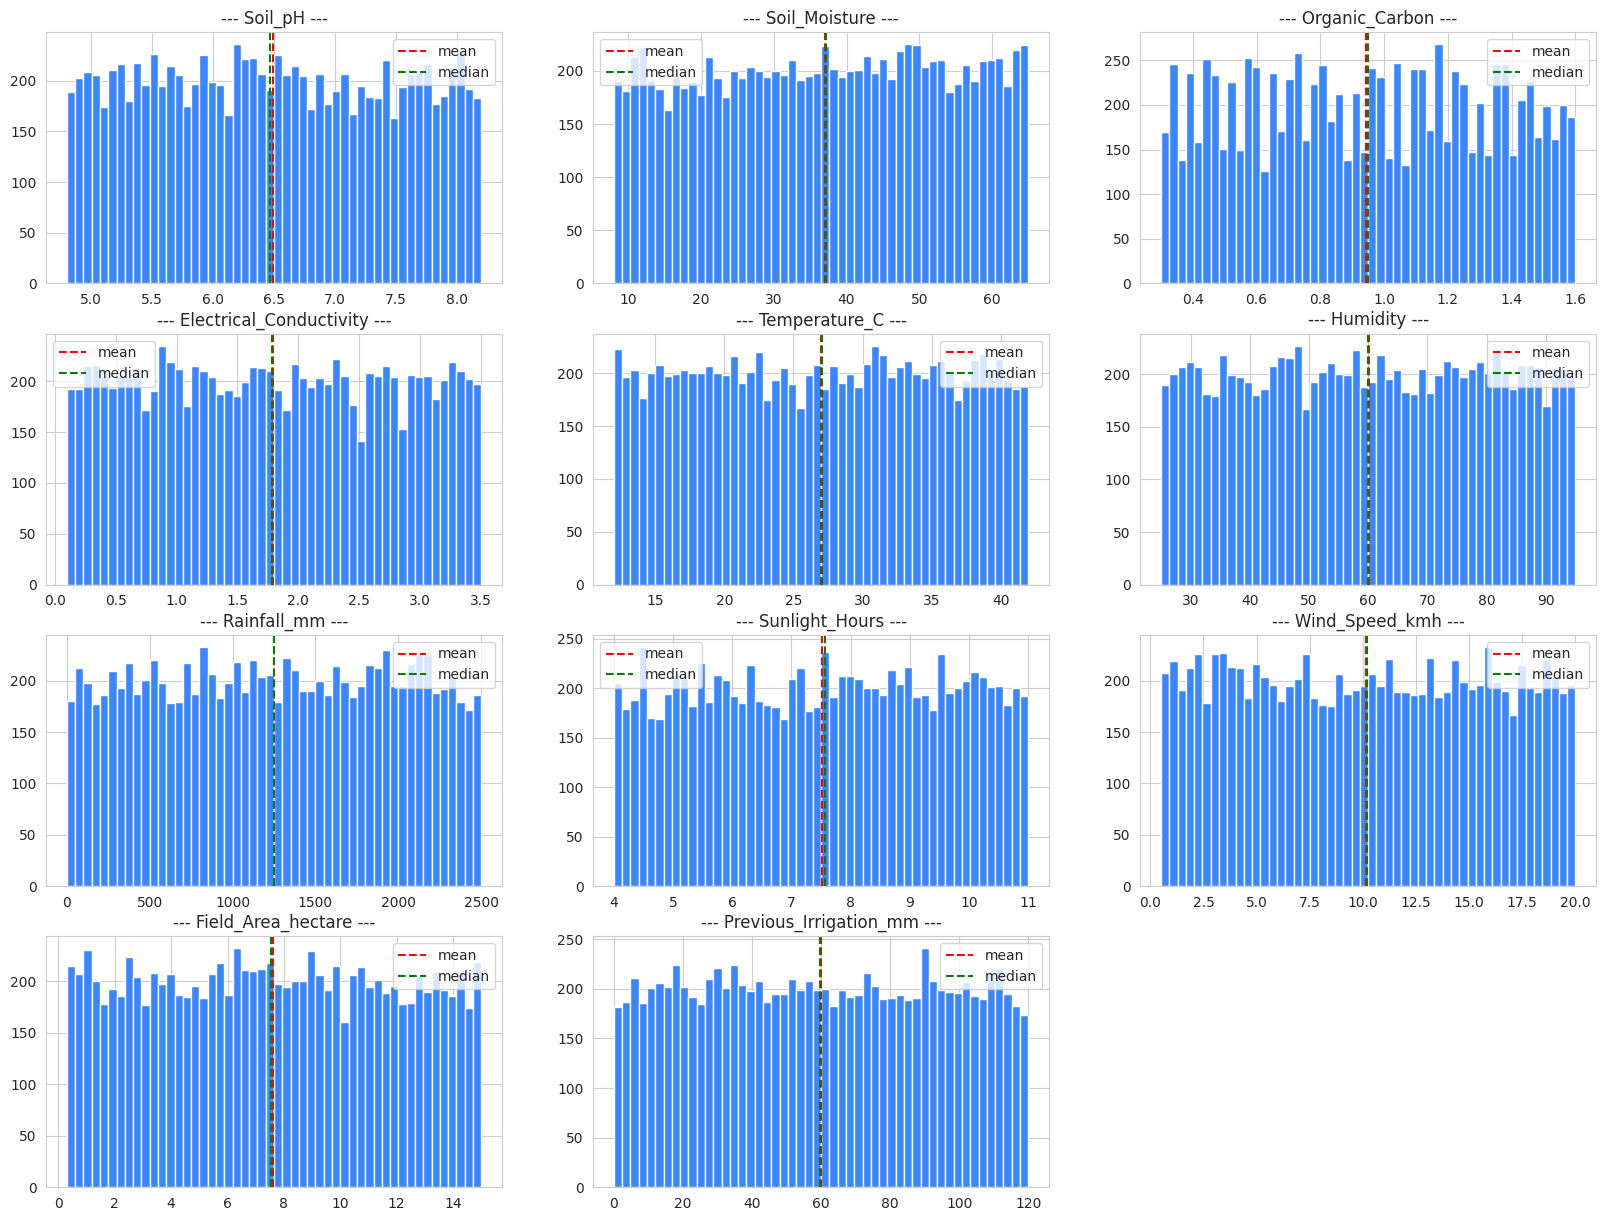

In [9]:
plt.figure(figsize=(20, 15))
for i, col in enumerate(NUMS):
    plt.subplot(4, 3, i+1)
    ax = plt.hist(orig[col], bins=50)
    plt.axvline(x=orig[col].mean(), color='r', linestyle='--', label='mean')
    plt.axvline(x=orig[col].median(), color='g', linestyle='--', label='median')
    plt.title(f'--- {col} ---')
    plt.legend()
    
plt.show()

In [10]:
## -- Unique value counts for each dataset --
TRAIN_UNIQUE = {}
ORIGINAL_UNIQUE = {}
TEST_UNIQUE = {}

for col in BASE:
    TRAIN_UNIQUE[col] = train[col].nunique()
    ORIGINAL_UNIQUE[col] = orig[col].nunique()
    TEST_UNIQUE[col] = test[col].nunique()

unique_counts_df = pd.concat(
        [pd.DataFrame(TRAIN_UNIQUE, index=['Train']),
         pd.DataFrame(ORIGINAL_UNIQUE, index=['Original']),
         pd.DataFrame(TEST_UNIQUE, index=['Test'])],
    )

unique_counts_df.style.background_gradient()

,Soil_pH,Soil_Moisture,Organic_Carbon,Electrical_Conductivity,Temperature_C,Humidity,Rainfall_mm,Sunlight_Hours,Wind_Speed_kmh,Field_Area_hectare,Previous_Irrigation_mm,Soil_Type,Crop_Type,Crop_Growth_Stage,Season,Irrigation_Type,Water_Source,Mulching_Used,Region
Train,341,5223,131,341,2934,6475,19308,701,1935,1466,10110,4,6,4,3,4,4,2,5
Original,341,4751,131,341,2897,5305,9813,701,1937,1470,6843,4,6,4,3,4,4,2,5
Test,341,4963,131,341,2864,6149,14483,700,1922,1452,9338,4,6,4,3,4,4,2,5


## FEATURE ENGINEERING

In [11]:
def get_weights(y, y_true, opt='auto'):
    """
    y: Current y labels -> numpy array or series
    y_true: True labels -> numpy array or series
    opt: 'auto' generate weight or pass a custom dict -> label: weight
    """
    if opt != 'auto':
        class_weights = opt
        sample_weights = np.array([class_weights[label] for label in y])
        return sample_weights
    else:
        classes_ = np.unique(y_true)
        weights_ = compute_class_weight('balanced', classes=classes_, y=y_true)
        class_weights = dict(zip(classes_, weights_))
        sample_weights = np.array([class_weights[label] for label in y])
        return sample_weights

def balanced_acc(y_true, y_preds):
    pred_labels = np.argmax(y_preds, axis=1)
    results = balanced_accuracy_score(y_true, pred_labels)
    return results

print('- Helper Functions Ready -')

- Helper Functions Ready -


Base  model training... Complete!
Permutation training... Complete!


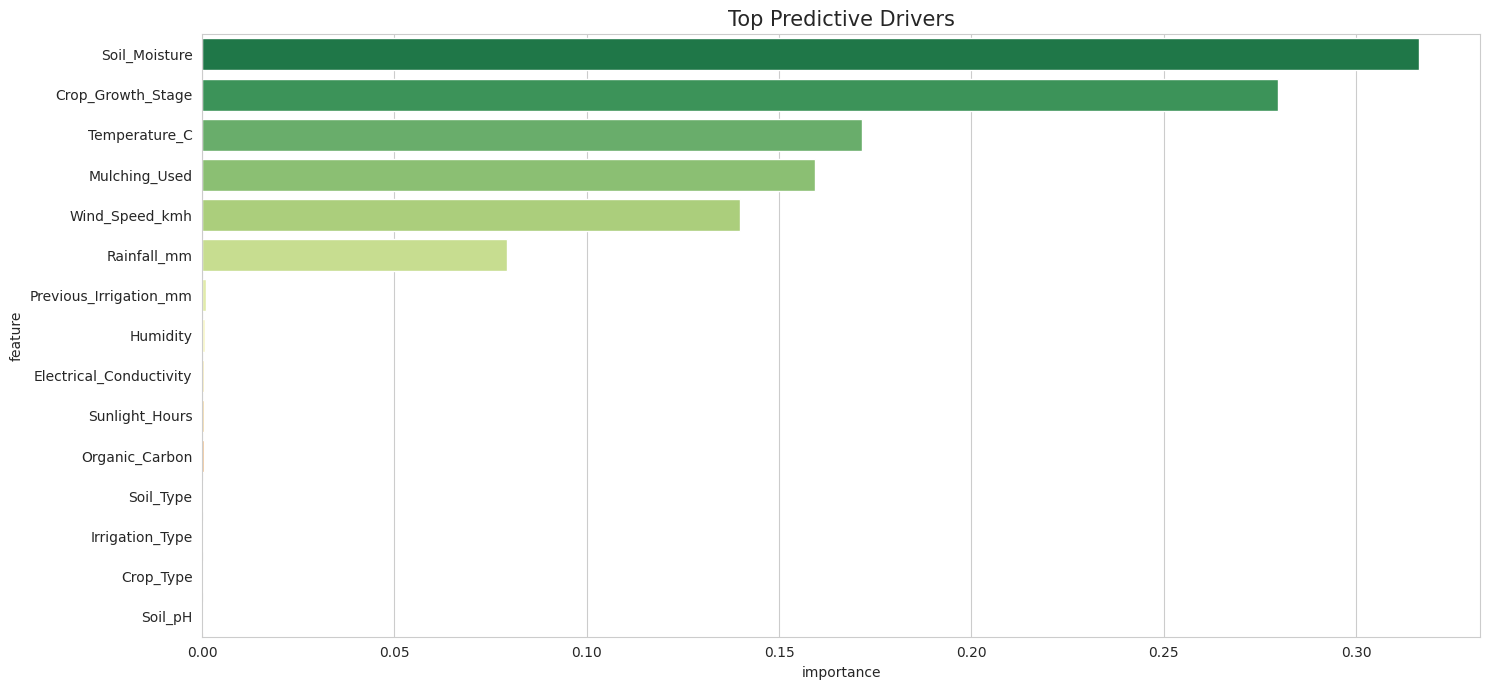

CPU times: user 20.3 s, sys: 265 ms, total: 20.6 s
Wall time: 1min 57s


,feature,importance
0,Soil_Moisture,0.316396
1,Crop_Growth_Stage,0.279775
2,Temperature_C,0.171483
3,Mulching_Used,0.159432
4,Wind_Speed_kmh,0.139910
5,Rainfall_mm,0.079348
6,Previous_Irrigation_mm,0.001115
7,Humidity,0.000826
8,Electrical_Conductivity,0.000489
9,Sunlight_Hours,0.000462


In [12]:
%%time 
from sklearn.inspection import permutation_importance

PARAMS = {
    'objective': 'multiclass',
    'metric': 'multiclass',
    'num_classes': 3,
    'random_state': SEED,
    'verbose': -1,
    'nthreads': -1,
    'device': 'gpu' if torch.cuda.is_available() else 'cpu',
}

X_1 = train[BASE]
y_1 = train[TARGET]

for c in CATS:
    X_1[c] = X_1[c].factorize()[0]
    X_1[c] = X_1[c].astype('category')

x_tr = X_1.sample(frac=0.75, random_state=SEED)
x_ts = X_1[~X_1.index.isin(x_tr.index)]

y_tr = y_1.loc[x_tr.index]
y_ts = y_1.loc[x_ts.index]

print('Base  model training... ', end='')
model = lgb.LGBMClassifier(**PARAMS).fit(x_tr, y_tr, sample_weight=get_weights(y_tr, y_1))
print('Complete!')

print('Permutation training... ', end='')
perm_importance = permutation_importance(
    model,
    x_ts,
    y_ts,
    n_repeats=5,
    sample_weight=get_weights(y_ts, y_tr),
    scoring='balanced_accuracy',
    random_state=SEED,
    n_jobs=-1,
)
print('Complete!')

importance_df = pd.DataFrame({
    'feature': BASE,
    'importance': perm_importance.importances_mean
}).sort_values(by='importance', ascending=False).reset_index(drop=True)

top_n = 15

plt.figure(figsize=(15, 7))
sns.barplot(data=importance_df.head(top_n), x='importance', y='feature', palette='RdYlGn_r')
plt.title('Top Predictive Drivers', fontsize=15)

plt.tight_layout()
plt.show()

importance_df.style.background_gradient(cmap='RdYlGn')

In [13]:
# importance_sr = pd.Series(
#     index=BASE, name='importance',
#     data=perm_importance.importances_mean
# ).sort_values(ascending=False)

# importance_sr.sort_values().plot.barh()
# plt.show()

In [14]:
## -- Top/Low features according to PERMUTATION IMPORTANCES --
TOP_COLS = ['Soil_Moisture', 'Temperature_C',
            'Wind_Speed_kmh', 'Rainfall_mm',
            'Mulching_Used', 'Crop_Growth_Stage']

LOW_COLS = [c for c in BASE if c not in TOP_COLS]

print(f"Top Features by PI: {TOP_COLS}")
print(f"Low Features by PI: {LOW_COLS}")

Top Features by PI: ['Soil_Moisture', 'Temperature_C', 'Wind_Speed_kmh', 'Rainfall_mm', 'Mulching_Used', 'Crop_Growth_Stage']
Low Features by PI: ['Soil_pH', 'Organic_Carbon', 'Electrical_Conductivity', 'Humidity', 'Sunlight_Hours', 'Field_Area_hectare', 'Previous_Irrigation_mm', 'Soil_Type', 'Crop_Type', 'Season', 'Irrigation_Type', 'Water_Source', 'Region']


In [15]:
# ## -- Optimal Binning --
# try:
#     import optbinning
# except:
#     %pip install -q -U optbinning
#     import optbinning

# def _opt_multiclass_binning(
#     x_tr, y_tr, x_vl, x_ts, bin_features,
#     solver='cp', metric='mean_woe', pre_bins=100, period=100):
#     """
#     metric: 'mean_woe' or 'weighted_mean_woe': floats or 'indices': integers
#     """
#     x_train = x_tr.copy()
#     x_val   = x_vl.copy()
#     x_test  = x_ts.copy()

#     opt_modules_per_col = []
#     opt_cols = []

#     # print(f'OptimalBinning {len(bin_features)}: ', end='')
#     for col in tqdm(bin_features, desc='Optimal_Multiclass_Binning'):
#         # print(f'{col}... ', end='')
#         opt_multi_b = optbinning.MulticlassOptimalBinning(
#             name=col,
#             prebinning_method='cart', # d='cart', 'quantile', 'uniform'
#             min_prebin_size=0.02, # d=0.05
#             max_n_prebins=pre_bins, # d=20
#             # min_n_bins=2, max_n_bins=100,
#             # min_bin_size=0.1, max_bin_size=0.9,
#             solver=solver,
#             time_limit=period, # d=100 (secs)
#             # verbose=True,
#         )

#         opt_multi_b.fit(x_train[col].to_numpy(), y_tr.to_numpy())
#         # display(optb.information(print_level=0))

#         new_col = f'{col}_optBin'
#         x_train[new_col] = opt_multi_b.transform(x_train[col].to_numpy(), metric=metric)
#         x_val[new_col]   = opt_multi_b.transform(x_val[col].to_numpy(),   metric=metric)
#         x_test[new_col]  = opt_multi_b.transform(x_test[col].to_numpy(),  metric=metric)

#         opt_cols.append(new_col)
#         opt_modules_per_col.append(opt_multi_b)

#     # print(f'Done!')

#     return opt_modules_per_col, opt_cols, x_train, x_val, x_test

# print('Binning function ready')

In [16]:
# opt_bins, opt_bin_cols, train2, orig2, test2 = _opt_multiclass_binning(
#     x_tr=train,
#     y_tr=train[TARGET],
#     x_vl=orig,
#     x_ts=test,
#     bin_features=NUMS,
#     solver='cp', # 'cp', 'mip', 'lr'
#     metric='mean_woe', # 'mean_woe','weighted_mean_woe','indices','bins'
#     pre_bins=100, 
#     period=100,
# )

# print(f"Total bin features: {len(opt_bin_cols)}")
# train2.head()

In [17]:
# BIN_TABLES = []

# for opt_ in opt_bins:
#     # print(opt_bins[col_n].status, opt_bins[col_n].splits)
#     opt_table = opt_.binning_table
#     opt_table.build()
#     # display(opt_table.build())
#     BIN_TABLES.append(opt_table)

# print('Optimal Binned Features:', len(BIN_TABLES))
# print('Classes:', BIN_TABLES[0].classes)

# ## -- Plot optimal bin points --
# for i, opt_ in enumerate(BIN_TABLES):
#     opt_.plot(show_bin_labels=True, figsize=(18, 5))
#     print()

In [18]:
# for col in opt_bin_cols:
#     print(f"{col}: {train2[col].nunique()}")

In [19]:
# BIN_TABLES[0].analysis()

In [20]:
## -- EXTRACTIONS & BINNING --
ROUNDS = []
DIGITS = []
E_BINS = []
Q_BINS = []
DROP_COLS = []

round_thresh = 3
digit_thresh = 2

round_thresh, digit_thresh

(3, 2)

In [21]:
FOUR_VALUES = ['Rainfall_mm']

print(f"\nROUNDING... ", end='')
for col in FOUR_VALUES:
    for r in [-2, -1, 0]:
        r_n = f"{col}_round_{r}"
        print(r_n+', ', end='')
        train[r_n] = train[col].round(r).astype('int32')
        test[r_n]  = test[col].round(r).astype('int32')
        orig[r_n]  = orig[col].round(r).astype('int32')

        ## -- Drop irrelevant features --
        if train[r_n].nunique() < round_thresh:
            DROP_COLS.append(r_n)
        elif train[r_n].nunique() == train[col].nunique():
            DROP_COLS.append(r_n)
        else:
            ROUNDS.append(r_n)

    print(f"\nDIGITS... ", end='')
    for d in [-3, -2, -1, 0, 1, 2]:
        d_n = f'{col}_digit_{d}'
        print(d_n+', ', end='')
        train[d_n] = ((train[col] * 10**d) % 10).fillna(-1).astype('int8')
        test[d_n]  = ((test[col]  * 10**d) % 10).fillna(-1).astype('int8')
        orig[d_n]  = ((orig[col]  * 10**d) % 10).fillna(-1).astype('int8')

        ## -- Drop constant features --
        if train[d_n].nunique() < digit_thresh:
            DROP_COLS.append(d_n)
        else:
            DIGITS.append(d_n)

    # print(f"\nCREATING E_BINS... ", end='')
    # for b in [400]: # 100, 500, 1000
    #     b_n = f'{col}_bin_{b}'
    #     print(b_n+', ', end='')
    #     train[b_n], edges = pd.cut(train[col], bins=b, retbins=True, include_lowest=True, labels=False)
    #     test[b_n] = pd.cut(test[col], bins=edges, include_lowest=True, labels=False)
    #     orig[b_n] = pd.cut(orig[col], bins=edges, include_lowest=True, labels=False)
    #     E_BINS.append(b_n)

    # print(f"\nQUANTILE BINNING... ", end='')
    # for q in [1000]: # 100, 500, 1000
    #     q_n = f'{col}_Qbin_{q}'
    #     print(q_n+', ', end='')
    #     train[q_n], edges = pd.qcut(train[col], q=q, retbins=True, duplicates='drop', labels=False)
    #     test[q_n] = pd.cut(test[col], bins=edges, include_lowest=True, labels=False)
    #     orig[q_n] = pd.cut(orig[col], bins=edges, include_lowest=True, labels=False)
    #     Q_BINS.append(q_n)

print()
print('='*50)
print(f'✅ Total ROUNDS: {len(ROUNDS)}')
print(f"✅ Total DIGITS: {len(DIGITS)}")
print(f"✅ Total E_BINS: {len(E_BINS)}")
print(f"✅ Total Q_BINS: {len(Q_BINS)}")


ROUNDING... Rainfall_mm_round_-2, Rainfall_mm_round_-1, Rainfall_mm_round_0, 
DIGITS... Rainfall_mm_digit_-3, Rainfall_mm_digit_-2, Rainfall_mm_digit_-1, Rainfall_mm_digit_0, Rainfall_mm_digit_1, Rainfall_mm_digit_2, 
✅ Total ROUNDS: 3
✅ Total DIGITS: 6
✅ Total E_BINS: 0
✅ Total Q_BINS: 0


In [22]:
THREE_VALUES = ['Previous_Irrigation_mm']

print(f"\nROUNDING... ", end='')
for col in THREE_VALUES:
    for r in [-1, 0]:
        r_n = f"{col}_round_{r}"
        print(r_n+', ', end='')
        train[r_n] = train[col].round(r).astype('int32')
        test[r_n]  = test[col].round(r).astype('int32')
        orig[r_n]  = orig[col].round(r).astype('int32')
        ## -- Drop irrelevant features --
        if train[r_n].nunique() < round_thresh:
            DROP_COLS.append(r_n)
        elif train[r_n].nunique() == train[col].nunique():
            DROP_COLS.append(r_n)
        else:
            ROUNDS.append(r_n)

    print(f"\nDIGITS... ", end='')
    for d in [-2, -1, 0, 1, 2]:
        d_n = f'{col}_digit_{d}'
        print(d_n+', ', end='')
        train[d_n] = ((train[col] * 10**d) % 10).fillna(-1).astype('int8')
        test[d_n]  = ((test[col]  * 10**d) % 10).fillna(-1).astype('int8')
        orig[d_n]  = ((orig[col]  * 10**d) % 10).fillna(-1).astype('int8')

        ## -- Drop constant features --
        if train[d_n].nunique() < digit_thresh:
            DROP_COLS.append(d_n)
        else:
            DIGITS.append(d_n)

    # print(f"\nEQUAL BINNING... ", end='')
    # for b in [100]: # 50, 100, 400
    #     b_n = f'{col}_bin_{b}'
    #     print(b_n+', ', end='')
    #     # Fit on train data and transform both train and test
    #     train[b_n], edges = pd.cut(train[col], bins=b, retbins=True, include_lowest=True, labels=False)
    #     test[b_n] = pd.cut(test[col], bins=edges, include_lowest=True, labels=False)
    #     orig[b_n] = pd.cut(orig[col], bins=edges, include_lowest=True, labels=False)
    #     E_BINS.append(b_n)
        
    # print(f"\nQUANTILE BINNING... ", end='')
    # for q in [500]: # 50, 100, 400
    #     q_n = f'{col}_Qbin_{q}'
    #     print(q_n+', ', end='')
    #     train[q_n], edges = pd.qcut(train[col], q=q, retbins=True, duplicates='drop', labels=False)
    #     test[q_n] = pd.cut(test[col], bins=edges, include_lowest=True, labels=False)
    #     orig[q_n] = pd.cut(orig[col], bins=edges, include_lowest=True, labels=False)
    #     Q_BINS.append(q_n)

print()
print('='*50)
print(f'✅ Total ROUNDS: {len(ROUNDS)}')
print(f"✅ Total DIGITS: {len(DIGITS)}")
print(f"✅ Total E_BINS: {len(E_BINS)}")
print(f"✅ Total Q_BINS: {len(Q_BINS)}")


ROUNDING... Previous_Irrigation_mm_round_-1, Previous_Irrigation_mm_round_0, 
DIGITS... Previous_Irrigation_mm_digit_-2, Previous_Irrigation_mm_digit_-1, Previous_Irrigation_mm_digit_0, Previous_Irrigation_mm_digit_1, Previous_Irrigation_mm_digit_2, 
✅ Total ROUNDS: 5
✅ Total DIGITS: 11
✅ Total E_BINS: 0
✅ Total Q_BINS: 0


In [23]:
TWO_VALUES = ['Soil_Moisture', 'Temperature_C', 'Wind_Speed_kmh'] + \
             ['Humidity', 'Sunlight_Hours', 'Field_Area_hectare']

print(f"\nROUNDING... ", end='')
for col in TWO_VALUES:
    for r in [-1, 0]:
        r_n = f"{col}_round_{r}"
        print(r_n+', ', end='')
        train[r_n] = train[col].round(r).astype('int32')
        test[r_n]  = test[col].round(r).astype('int32')
        orig[r_n]  = orig[col].round(r).astype('int32')
    
        ## -- Drop irrelevant features --
        if train[r_n].nunique() < round_thresh:
            DROP_COLS.append(r_n)
        elif train[r_n].nunique() == train[col].nunique():
            DROP_COLS.append(r_n)
        else:
            ROUNDS.append(r_n)

    print(f"\nDIGITS... ", end='')
    for d in [-1, 0, 1, 2]:
        d_n = f'{col}_digit_{d}'
        print(d_n+', ', end='')
        train[d_n] = ((train[col] * 10**d) % 10).fillna(-1).astype('int8')
        test[d_n]  = ((test[col]  * 10**d) % 10).fillna(-1).astype('int8')
        orig[d_n]  = ((orig[col]  * 10**d) % 10).fillna(-1).astype('int8')

        ## -- Drop constant features --
        if train[d_n].nunique() < digit_thresh:
            DROP_COLS.append(d_n)
        else:
            DIGITS.append(d_n)

    # print(f"\nEQUAL BINNING... ", end='')
    # for b in [10, 50]: # 10, 50, 100
    #     b_n = f'{col}_bin_{b}'
    #     print(b_n+', ', end='')
    #     # Fit on train data and transform both train and test
    #     train[b_n], edges = pd.cut(train[col], bins=b, retbins=True, include_lowest=True, labels=False)
    #     test[b_n] = pd.cut(test[col], bins=edges, include_lowest=True, labels=False)
    #     orig[b_n] = pd.cut(orig[col], bins=edges, include_lowest=True, labels=False)
    #     E_BINS.append(b_n)

    # print(f"\nQUANTILE BINNING... ", end='')
    # for q in [10, 50]: # 10, 50, 100
    #     q_n = f'{col}_Qbin_{q}'
    #     print(q_n+', ', end='')
    #     train[q_n], edges = pd.qcut(train[col], q=q, retbins=True, duplicates='drop', labels=False)
    #     test[q_n] = pd.cut(test[col], bins=edges, include_lowest=True, labels=False)
    #     orig[q_n]  = pd.cut(orig[col], bins=edges, include_lowest=True, labels=False)
    #     Q_BINS.append(q_n)

print()
print('='*50)
print(f'✅ Total ROUNDS: {len(ROUNDS)}')
print(f"✅ Total DIGITS: {len(DIGITS)}")
print(f"✅ Total E_BINS: {len(E_BINS)}")
print(f"✅ Total Q_BINS: {len(Q_BINS)}")


ROUNDING... Soil_Moisture_round_-1, Soil_Moisture_round_0, 
DIGITS... Soil_Moisture_digit_-1, Soil_Moisture_digit_0, Soil_Moisture_digit_1, Soil_Moisture_digit_2, Temperature_C_round_-1, Temperature_C_round_0, 
DIGITS... Temperature_C_digit_-1, Temperature_C_digit_0, Temperature_C_digit_1, Temperature_C_digit_2, Wind_Speed_kmh_round_-1, Wind_Speed_kmh_round_0, 
DIGITS... Wind_Speed_kmh_digit_-1, Wind_Speed_kmh_digit_0, Wind_Speed_kmh_digit_1, Wind_Speed_kmh_digit_2, Humidity_round_-1, Humidity_round_0, 
DIGITS... Humidity_digit_-1, Humidity_digit_0, Humidity_digit_1, Humidity_digit_2, Sunlight_Hours_round_-1, Sunlight_Hours_round_0, 
DIGITS... Sunlight_Hours_digit_-1, Sunlight_Hours_digit_0, Sunlight_Hours_digit_1, Sunlight_Hours_digit_2, Field_Area_hectare_round_-1, Field_Area_hectare_round_0, 
DIGITS... Field_Area_hectare_digit_-1, Field_Area_hectare_digit_0, Field_Area_hectare_digit_1, Field_Area_hectare_digit_2, 
✅ Total ROUNDS: 16
✅ Total DIGITS: 35
✅ Total E_BINS: 0
✅ Total Q_BI

In [24]:
ONE_VALUE = ['Soil_pH', 'Organic_Carbon', 'Electrical_Conductivity']

print(f"\nROUNDING... ", end='')
for col in ONE_VALUE:
    for r in [0, 1]:
        r_n = f"{col}_round_{r}"
        print(r_n+', ', end='')
        train[r_n] = train[col].round(r).astype('int32')
        test[r_n]  = test[col].round(r).astype('int32')
        orig[r_n]  = orig[col].round(r).astype('int32')

        ## -- Drop irrelevant features --
        if train[r_n].nunique() < round_thresh:
            DROP_COLS.append(r_n)
        elif train[r_n].nunique() == train[col].nunique():
            DROP_COLS.append(r_n)
        else:
            ROUNDS.append(r_n)

    print(f"\nDIGITS... ", end='')
    for d in [0, 1, 2]:
        d_n = f'{col}_digit_{d}'
        print(d_n+', ', end='')
        train[d_n] = ((train[col] * 10**d) % 10).fillna(-1).astype('int8')
        test[d_n]  = ((test[col]  * 10**d) % 10).fillna(-1).astype('int8')
        orig[d_n]  = ((orig[col]  * 10**d) % 10).fillna(-1).astype('int8')

        ## -- Drop constant features --
        if train[d_n].nunique() < digit_thresh:
            DROP_COLS.append(d_n)
        else:
            DIGITS.append(d_n)

    # print(f"\nEQUAL BINNING... ", end='')
    # for b in [10, 50]: # 10, 50, 100
    #     b_n = f'{col}_bin_{b}'
    #     print(b_n+', ', end='')
    #     # Fit on train data and transform both train and test
    #     train[b_n], edges = pd.cut(train[col], bins=b, retbins=True, include_lowest=True, labels=False)
    #     test[b_n] = pd.cut(test[col], bins=edges, include_lowest=True, labels=False)
    #     orig[b_n] = pd.cut(orig[col], bins=edges, include_lowest=True, labels=False)
    #     E_BINS.append(b_n)

    # print(f"\nQUANTILE BINNING... ", end='')
    # for q in [10, 50]: # 10, 50, 100
    #     q_n = f'{col}_Qbin_{q}'
    #     print(q_n+', ', end='')
    #     train[q_n], edges = pd.qcut(train[col], q=q, retbins=True, duplicates='drop', labels=False)
    #     test[q_n] = pd.cut(test[col], bins=edges, include_lowest=True, labels=False)
    #     orig[q_n]  = pd.cut(orig[col], bins=edges, include_lowest=True, labels=False)
    #     Q_BINS.append(q_n)

print()
print('='*50)
print(f'✅ Total ROUNDS: {len(ROUNDS)}')
print(f"✅ Total DIGITS: {len(DIGITS)}")
print(f"✅ Total E_BINS: {len(E_BINS)}")
print(f"✅ Total Q_BINS: {len(Q_BINS)}")


ROUNDING... Soil_pH_round_0, Soil_pH_round_1, 
DIGITS... Soil_pH_digit_0, Soil_pH_digit_1, Soil_pH_digit_2, Organic_Carbon_round_0, Organic_Carbon_round_1, 
DIGITS... Organic_Carbon_digit_0, Organic_Carbon_digit_1, Organic_Carbon_digit_2, Electrical_Conductivity_round_0, Electrical_Conductivity_round_1, 
DIGITS... Electrical_Conductivity_digit_0, Electrical_Conductivity_digit_1, Electrical_Conductivity_digit_2, 
✅ Total ROUNDS: 21
✅ Total DIGITS: 44
✅ Total E_BINS: 0
✅ Total Q_BINS: 0


In [25]:
train = train.drop(columns=DROP_COLS)
test  = test.drop(columns=DROP_COLS)
orig  = orig.drop(columns=DROP_COLS)

print(f"Features dropped: {DROP_COLS}")

Features dropped: ['Sunlight_Hours_round_-1', 'Organic_Carbon_round_1']


In [26]:
def add_frequency_condition(df1, cols, thresh=5):
    df = df1.copy()
    for c in cols:
        # 1. Get value counts
        v_counts = df[c].value_counts()
        # 2. Identify values to replace (count <= threshold)
        to_replace = v_counts[v_counts <= thresh].index
        # 3. Apply condition: if value in low-freq list, assign 0, else keep it
        df[c] = np.where(df[c].isin(to_replace), -1, df[c])

    return df

train = add_frequency_condition(train, DIGITS+ROUNDS, thresh=5)
test  = add_frequency_condition(test,  DIGITS+ROUNDS, thresh=5)
orig  = add_frequency_condition(orig,  DIGITS+ROUNDS, thresh=5)

print(f"Frequency threshold imputed!")

Frequency threshold imputed!


In [27]:
# LOW_CATS_UNIQUE = []

# for col in ALL_ROUND_BINS:
#     if train[col].nunique() < 100:
#         LOW_CATS_UNIQUE.append(col)

# print(f"Cats with ~100 unique: {len(LOW_CATS_UNIQUE)}")
# print()
# TOP_CATS_UNIQUE = [c for c in ALL_ROUND_BINS if c not in LOW_CATS_UNIQUE]
# print(f"Cats with +100 unique: {len(TOP_CATS_UNIQUE)}")

In [28]:
# ## -- Arithmetic interaction --
# for df in [train, test, orig]:
#     df['_MonthlyCharges_/_TotalCharges'] = (df['MonthlyCharges'] / (df['TotalCharges'] + 1e-6)).astype('float32')
#     df['_TotalCharges_/_tenure']  = (df['TotalCharges'] / (df['tenure'] + 1e-6)).astype('float32')
#     df['_Monthly_to_avg_ratio'] = (df['MonthlyCharges'] / (df['_TotalCharges_/_tenure'] + 1e-6)).astype('float32')
#     df['_TotalCharges_/_MonthlyCharges']  = (df['TotalCharges'] / (df['MonthlyCharges'] + 1e-6)).astype('float32')
#     df['_tenure_sq'] = (df['tenure'] ** 2).astype("float32")

# arithmetic = ['_MonthlyCharges_/_TotalCharges', '_TotalCharges_/_tenure',
#               '_Monthly_to_avg_ratio', '_TotalCharges_/_MonthlyCharges', '_tenure_sq']

# train[arithmetic].head()

In [29]:
# ## -- Cyclic encoding --
# for df in [train, test, orig]:
#     for p in [12, 30]:
#         df[f"MonthlyCharges_sin_{p}"] = np.sin(2 * np.pi * df['MonthlyCharges'] / p).astype('float32')
#         df[f"MonthlyCharges_cos_{p}"] = np.cos(2 * np.pi * df['MonthlyCharges'] / p).astype('float32')

In [30]:
# ## -- FREQUENCY ENCODING --
# NUMS_FREQ = []
# print(f"\nCREATING FREQUENCIES... ", end='')
# for col in NUMS:
#     freq = pd.concat([train[col], orig[col], test[col]]).value_counts(normalize=True)
#     n = f'{col}_FREQ'
#     print(n+', ', end='')
#     for df in [train, test, orig]:
#         df[n] = df[col].map(freq).fillna(0).astype('float32')
#     NUMS_FREQ.append(n)

# print()
# print(f"✅ TOTAL FREQUENCY FEEATURES: {len(NUMS_FREQ)}")

In [31]:
sleep(5); gc.collect()

195

In [32]:
INTER = []

for c1, c2 in tqdm(list(itertools.combinations(TOP_COLS, 2)), desc='Pairwise'):
    n_col = f"Bi_{c1}-|-{c2}"
    train[n_col] = train[c1].astype(str) + '_' + train[c2].astype(str)
    test[n_col]  = test[c1].astype(str) + '_' + test[c2].astype(str)
    orig[n_col]  = orig[c1].astype(str) + '_' + orig[c2].astype(str)
    INTER.append(n_col)

for c1, c2, c3 in tqdm(list(itertools.combinations(TOP_COLS, 3)), desc='Triplewise'):
    n_col = f"Tri_{c1}-|-{c2}-|-{c3}"
    train[n_col] = train[c1].astype(str) + '_' + train[c2].astype(str) + '_' + train[c3].astype(str)
    test[n_col]  = test[c1].astype(str) + '_' + test[c2].astype(str) + '_' + test[c3].astype(str)
    orig[n_col]  = orig[c1].astype(str) + '_' + orig[c2].astype(str) + '_' + test[c3].astype(str)
    INTER.append(n_col)

for c1, c2 in tqdm(list(itertools.product(TOP_COLS, LOW_COLS)), desc='One-to-Many'):
    n_col = f"Bi_{c1}-|-{c2}"
    train[n_col] = train[c1].astype(str) + '_' + train[c2].astype(str)
    test[n_col]  = test[c1].astype(str) + '_' + test[c2].astype(str)
    orig[n_col]  = orig[c1].astype(str) + '_' + orig[c2].astype(str)
    INTER.append(n_col)

print(f"Total Interaction Features: {len(INTER)}")

Pairwise:   0%|          | 0/15 [00:00<?, ?it/s]

Triplewise:   0%|          | 0/20 [00:00<?, ?it/s]

One-to-Many:   0%|          | 0/78 [00:00<?, ?it/s]

Total Interaction Features: 113


In [33]:
sleep(5); gc.collect()

5491

In [34]:
train[INTER].head()

,Bi_Soil_Moisture-|-Temperature_C,Bi_Soil_Moisture-|-Wind_Speed_kmh,Bi_Soil_Moisture-|-Rainfall_mm,Bi_Soil_Moisture-|-Mulching_Used,Bi_Soil_Moisture-|-Crop_Growth_Stage,Bi_Temperature_C-|-Wind_Speed_kmh,Bi_Temperature_C-|-Rainfall_mm,Bi_Temperature_C-|-Mulching_Used,Bi_Temperature_C-|-Crop_Growth_Stage,Bi_Wind_Speed_kmh-|-Rainfall_mm,Bi_Wind_Speed_kmh-|-Mulching_Used,Bi_Wind_Speed_kmh-|-Crop_Growth_Stage,Bi_Rainfall_mm-|-Mulching_Used,Bi_Rainfall_mm-|-Crop_Growth_Stage,Bi_Mulching_Used-|-Crop_Growth_Stage,Tri_Soil_Moisture-|-Temperature_C-|-Wind_Speed_kmh,Tri_Soil_Moisture-|-Temperature_C-|-Rainfall_mm,Tri_Soil_Moisture-|-Temperature_C-|-Mulching_Used,Tri_Soil_Moisture-|-Temperature_C-|-Crop_Growth_Stage,Tri_Soil_Moisture-|-Wind_Speed_kmh-|-Rainfall_mm,Tri_Soil_Moisture-|-Wind_Speed_kmh-|-Mulching_Used,Tri_Soil_Moisture-|-Wind_Speed_kmh-|-Crop_Growth_Stage,Tri_Soil_Moisture-|-Rainfall_mm-|-Mulching_Used,Tri_Soil_Moisture-|-Rainfall_mm-|-Crop_Growth_Stage,Tri_Soil_Moisture-|-Mulching_Used-|-Crop_Growth_Stage,Tri_Temperature_C-|-Wind_Speed_kmh-|-Rainfall_mm,Tri_Temperature_C-|-Wind_Speed_kmh-|-Mulching_Used,Tri_Temperature_C-|-Wind_Speed_kmh-|-Crop_Growth_Stage,Tri_Temperature_C-|-Rainfall_mm-|-Mulching_Used,Tri_Temperature_C-|-Rainfall_mm-|-Crop_Growth_Stage,Tri_Temperature_C-|-Mulching_Used-|-Crop_Growth_Stage,Tri_Wind_Speed_kmh-|-Rainfall_mm-|-Mulching_Used,Tri_Wind_Speed_kmh-|-Rainfall_mm-|-Crop_Growth_Stage,Tri_Wind_Speed_kmh-|-Mulching_Used-|-Crop_Growth_Stage,Tri_Rainfall_mm-|-Mulching_Used-|-Crop_Growth_Stage,Bi_Soil_Moisture-|-Soil_pH,Bi_Soil_Moisture-|-Organic_Carbon,Bi_Soil_Moisture-|-Electrical_Conductivity,Bi_Soil_Moisture-|-Humidity,Bi_Soil_Moisture-|-Sunlight_Hours,Bi_Soil_Moisture-|-Field_Area_hectare,Bi_Soil_Moisture-|-Previous_Irrigation_mm,Bi_Soil_Moisture-|-Soil_Type,Bi_Soil_Moisture-|-Crop_Type,Bi_Soil_Moisture-|-Season,Bi_Soil_Moisture-|-Irrigation_Type,Bi_Soil_Moisture-|-Water_Source,Bi_Soil_Moisture-|-Region,Bi_Temperature_C-|-Soil_pH,Bi_Temperature_C-|-Organic_Carbon,Bi_Temperature_C-|-Electrical_Conductivity,Bi_Temperature_C-|-Humidity,Bi_Temperature_C-|-Sunlight_Hours,Bi_Temperature_C-|-Field_Area_hectare,Bi_Temperature_C-|-Previous_Irrigation_mm,Bi_Temperature_C-|-Soil_Type,Bi_Temperature_C-|-Crop_Type,Bi_Temperature_C-|-Season,Bi_Temperature_C-|-Irrigation_Type,Bi_Temperature_C-|-Water_Source,Bi_Temperature_C-|-Region,Bi_Wind_Speed_kmh-|-Soil_pH,Bi_Wind_Speed_kmh-|-Organic_Carbon,Bi_Wind_Speed_kmh-|-Electrical_Conductivity,Bi_Wind_Speed_kmh-|-Humidity,Bi_Wind_Speed_kmh-|-Sunlight_Hours,Bi_Wind_Speed_kmh-|-Field_Area_hectare,Bi_Wind_Speed_kmh-|-Previous_Irrigation_mm,Bi_Wind_Speed_kmh-|-Soil_Type,Bi_Wind_Speed_kmh-|-Crop_Type,Bi_Wind_Speed_kmh-|-Season,Bi_Wind_Speed_kmh-|-Irrigation_Type,Bi_Wind_Speed_kmh-|-Water_Source,Bi_Wind_Speed_kmh-|-Region,Bi_Rainfall_mm-|-Soil_pH,Bi_Rainfall_mm-|-Organic_Carbon,Bi_Rainfall_mm-|-Electrical_Conductivity,Bi_Rainfall_mm-|-Humidity,Bi_Rainfall_mm-|-Sunlight_Hours,Bi_Rainfall_mm-|-Field_Area_hectare,Bi_Rainfall_mm-|-Previous_Irrigation_mm,Bi_Rainfall_mm-|-Soil_Type,Bi_Rainfall_mm-|-Crop_Type,Bi_Rainfall_mm-|-Season,Bi_Rainfall_mm-|-Irrigation_Type,Bi_Rainfall_mm-|-Water_Source,Bi_Rainfall_mm-|-Region,Bi_Mulching_Used-|-Soil_pH,Bi_Mulching_Used-|-Organic_Carbon,Bi_Mulching_Used-|-Electrical_Conductivity,Bi_Mulching_Used-|-Humidity,Bi_Mulching_Used-|-Sunlight_Hours,Bi_Mulching_Used-|-Field_Area_hectare,Bi_Mulching_Used-|-Previous_Irrigation_mm,Bi_Mulching_Used-|-Soil_Type,Bi_Mulching_Used-|-Crop_Type,Bi_Mulching_Used-|-Season,Bi_Mulching_Used-|-Irrigation_Type,Bi_Mulching_Used-|-Water_Source,Bi_Mulching_Used-|-Region,Bi_Crop_Growth_Stage-|-Soil_pH,Bi_Crop_Growth_Stage-|-Organic_Carbon,Bi_Crop_Growth_Stage-|-Electrical_Conductivity,Bi_Crop_Growth_Stage-|-Humidity,Bi_Crop_Growth_Stage-|-Sunlight_Hours,Bi_Crop_Growth_Stage-|-Field_Area_hectare,Bi_Crop_Growth_Stage-|-Previous_Irrigation_mm,Bi_Crop_Growth_Stage-|-Soil_Type,Bi_Crop_Growth_Stage-|-Crop_Type,Bi_Crop_Growth_St

In [35]:
# ## -- Reduce data memory --
# def reduce_memory(df):
#     old_size = sys.getsizeof(df) / (1024*1024)
#     for c in tqdm(df.columns, desc='Reducing memory...'):
#         ## -- Downcast Integer type ---
#         if df[c].dtype == np.int64: 
#             if df[c].min() > np.iinfo(np.int32).min and df[c].max() < np.iinfo(np.int32).max:
#                 df[c] = df[c].astype(np.int32)
#                 # if df[c].min() > np.iinfo(np.int16).min and df[c].max() < np.iinfo(np.int16).max:
#                 #     df[c] = df[c].astype(np.int16)
#                 #     if df[c].min() > np.iinfo(np.int8).min and df[c].max() < np.iinfo(np.int8).max:
#                 #         df[c] = df[c].astype(np.int8)
#         ## -- Downcast Float type -----
#         # elif df[c].dtype == np.float64:
#         #     if df[c].min() > np.finfo(np.float32).min and df[c].max() < np.finfo(np.float32).max:
#         #         df[c] = df[c].astype(np.float32)
#                 # if df[c].min() > np.finfo(np.float16).min and df[c].max() < np.finfo(np.float16).max:
#                 #     df[c] = df[c].astype(np.float16)

#     new_size = sys.getsizeof(df) / (1024*1024)
#     print(f"Size before process: {old_size:.1f}MB")
#     print(f"Size after process : {new_size:.1f}MB\n")
    
#     return df

# train = reduce_memory(train)
# test = reduce_memory(test)
# orig = reduce_memory(orig)

# gc.collect()

# print(f"Data memory reduced!")

In [36]:
from sklearn.base import BaseEstimator, TransformerMixin ## ===== CategoryMeanEncoder =====

class CategoryMeanTransformer(BaseEstimator, TransformerMixin):
    def __init__(self, cat_cols=None):
        self.cat_cols = cat_cols
        self.mappings_ = {}
    def fit(self, X, y):
        X = X.copy()
        if self.cat_cols is None:
            self.cat_cols = X.select_dtypes(include=['category']).columns.tolist()
        self.mappings_ = {}
        for col in self.cat_cols:
            df_temp = pd.DataFrame({col: X[col], 'y': y})
            group_means = df_temp.groupby(col, dropna=False)['y'].mean()
            sorted_categories = group_means.sort_values().index
            self.mappings_[col] = {cat: i for i, cat in enumerate(sorted_categories)}
        return self

    def transform(self, X, y=None):
        X = X.copy()
        for col, mapping in self.mappings_.items():
            if col in X.columns:
                X[col] = X[col].map(mapping)
        return X

In [37]:
def orig_TE_data_propagate(
    orig: pd.DataFrame,
    X_train: pd.DataFrame,
    X_val: pd.DataFrame,
    X_test: pd.DataFrame,
    features: list=None,
    target: str=None,
    aggs: list=None,
    fill_nan: bool=False,
):

    if features is None or len(features) == 0:
        return X_train.copy(), X_val.copy(), X_test.copy(), []

    if aggs is None or len(aggs) == 0:
        return X_train.copy(), X_val.copy(), X_test.copy(), []

    X_train_df = X_train.copy()
    X_val_df   = X_val.copy()
    X_test_df  = X_test.copy()
    ORIG = []

    maps = {}

    valid_features = [col for col in features if col in orig.columns]

    for col in tqdm(valid_features, desc='TE_merging'):
        for agg_ in aggs:
            agg_key = agg_.lower()
            new_col = f"OTE_{col}_{agg_key}"

            map_key = (col, agg_key)
            if map_key not in maps:
                try:
                    if agg_key == 'mean':
                        map_df = (orig.groupby(col)[target].mean().reset_index(name=new_col))
                    elif agg_key == 'median':
                        map_df = (orig.groupby(col)[target].median().reset_index(name=new_col))
                    elif agg_key == 'count':
                        map_df = (orig.groupby(col).size().reset_index(name=new_col))
                    elif agg_key == 'nunique':
                        map_df = (orig.groupby(col)[target].nunique().reset_index(name=new_col))
                    elif agg_key == 'std':
                        map_df = (orig.groupby(col)[target].std().reset_index(name=new_col))
                    elif agg_key == 'skew':
                        map_df = (orig.groupby(col)[target].skew().reset_index(name=new_col))
                    elif agg_key == 'max':
                        map_df = (orig.groupby(col)[target].max().reset_index(name=new_col))
                    elif agg_key == 'min':
                        map_df = (orig.groupby(col)[target].min().reset_index(name=new_col))
                    else:
                        continue
                except Exception as e:
                    print(f"Warning: failed to create map for col={col}, agg={agg_}: {e}")
                    continue

                maps[map_key] = map_df

            map_df = maps.get(map_key)
            if map_df is None:
                continue

            # Merge maps into each split
            X_train_df = X_train_df.merge(map_df, on=col, how='left')
            X_val_df   = X_val_df.merge(map_df, on=col, how='left')
            X_test_df  = X_test_df.merge(map_df, on=col, how='left')

            ORIG.append(new_col)

    global_mean   = orig[target].mean()
    global_median = orig[target].median()
    
    def fill_conditionally(df):
        for c in ORIG:
            if '_mean' in c or '_max' in c or '_min' in c:
                df[c] = df[c].fillna(global_mean)
            elif '_median' in c:
                df[c] = df[c].fillna(global_median)
            else:
                df[c] = df[c].fillna(0)
        return df

    if fill_nan:
        X_train_df = fill_conditionally(X_train_df)
        X_val_df   = fill_conditionally(X_val_df)
        X_test_df  = fill_conditionally(X_test_df)

    return X_train_df, X_val_df, X_test_df, ORIG

In [38]:
train, test, _, ORIG_COLS = orig_TE_data_propagate(
    orig,
    train,
    test,
    train.iloc[:500],
    features=BASE,
    target=TARGET,
    aggs=['mean'], # mean, median, count, std, skew, nunique, max, min
    # fill_nan=True,
)

print(f"Total original features: {len(ORIG_COLS)}")

TE_merging:   0%|          | 0/19 [00:00<?, ?it/s]

Total original features: 19


In [39]:
## -- BINARY FORMULA --
def add_FE_formula(df1):
    df = df1.copy()

    # 4 Boolean numeric features based on threshold insights
    df['soil_lt_25']  = (df['Soil_Moisture'] < 25).astype('int8')  # <25
    df['temp_gt_30']  = (df['Temperature_C'] > 30).astype('int8')  # >30
    df['rain_lt_300'] = (df['Rainfall_mm'] < 300).astype('int8')   # <300
    df['wind_gt_10']  = (df['Wind_Speed_kmh'] > 10).astype('int8') # >10
    return df

train = add_FE_formula(train)
test  = add_FE_formula(test)
orig  = add_FE_formula(orig)

FORMULA_FLAGS = train.columns.tolist()[-4:]
print(f"Formula flags: {FORMULA_FLAGS}")


## -- LOGIT FORMULA --
for df_ in [train, test]:
    df = pd.get_dummies(df_, columns=CATS, drop_first=False)

    df_['logit(P(y=Low))'] = 16.3173 + (-11.0237 * df["soil_lt_25"]) + (-5.8559 * df["temp_gt_30"]) + (-10.8500 * df["rain_lt_300"]) + (-5.8284 * df["wind_gt_10"]) + (-5.4155 * df["Crop_Growth_Stage_Flowering"]) + (5.5073 * df["Crop_Growth_Stage_Harvest"]) + (5.2299 * df["Crop_Growth_Stage_Sowing"]) + (-5.4617 * df["Crop_Growth_Stage_Vegetative"]) + (-3.0014 * df["Mulching_Used_No"]) + (2.8613 * df["Mulching_Used_Yes"])
    df_['logit(P(y=Medium))'] = 4.6524 + (0.3290 * df["soil_lt_25"]) + (-0.0204 * df["temp_gt_30"]) + (0.1542 * df["rain_lt_300"]) + (0.0841 * df["wind_gt_10"]) + (0.3586 * df["Crop_Growth_Stage_Flowering"]) + (-0.1348 * df["Crop_Growth_Stage_Harvest"]) + (-0.3547 * df["Crop_Growth_Stage_Sowing"]) + (0.3334 * df["Crop_Growth_Stage_Vegetative"]) + (0.1883 * df["Mulching_Used_No"]) + (0.0142 * df["Mulching_Used_Yes"])
    df_['logit(P(y=High))'] = -20.9697 + (10.6947 * df["soil_lt_25"]) + (5.8763 * df["temp_gt_30"]) + (10.6958 * df["rain_lt_300"]) + (5.7444 * df["wind_gt_10"]) + (5.0569 * df["Crop_Growth_Stage_Flowering"]) + (-5.3725 * df["Crop_Growth_Stage_Harvest"]) + (-4.8752 * df["Crop_Growth_Stage_Sowing"]) + (5.1283 * df["Crop_Growth_Stage_Vegetative"]) + (2.8131 * df["Mulching_Used_No"]) + (-2.8755 * df["Mulching_Used_Yes"])

LOGIT_COLS = ['logit(P(y=Low))', 'logit(P(y=Medium))', 'logit(P(y=High))']
print(f"Formula logit: {LOGIT_COLS}")

Formula flags: ['soil_lt_25', 'temp_gt_30', 'rain_lt_300', 'wind_gt_10']
Formula logit: ['logit(P(y=Low))', 'logit(P(y=Medium))', 'logit(P(y=High))']


In [40]:
## -- Duplicate all numerics as categories --
CATS_2 = []

for c in BASE:
    n = f"cat_{c}"
    train[n] = train[c].copy()
    test[n]  = test[c].copy()
    orig[n]  = orig[c].copy()
    CATS_2.append(n)

    ## -- FACTORIZE CATS_2 --
    combine  = pd.concat([train[n], test[n], orig[n]])
    v = combine.factorize()[0]
    train[n] = v[:len(train)].astype('int32')
    test[n]  = v[len(train):len(train)+len(test)].astype('int32')
    orig[n]  = v[len(train)+len(test):].astype('int32')

print(f'Numericals to Categoricals: {len(CATS_2)}')

Numericals to Categoricals: 19


In [41]:
## -- Factorize using combined data --
for c in CATS:
    combine  = pd.concat([train[c], test[c], orig[c]])
    combine  = combine.factorize()[0]
    # combine  = pd.Series(combine).astype('category')
    train[c] = combine[:len(train)]
    test[c]  = combine[len(train):len(train)+len(test)]
    orig[c]  = combine[-len(orig):]

print('Label encoding complete!')

Label encoding complete!


In [42]:
FEATURES = [c for c in train.columns if c not in ['id', TARGET]]
print('Total Features:', len(FEATURES))

train.head(3)

Total Features: 242


,Soil_Type,Soil_pH,Soil_Moisture,Organic_Carbon,Electrical_Conductivity,Temperature_C,Humidity,Rainfall_mm,Sunlight_Hours,Wind_Speed_kmh,Crop_Type,Crop_Growth_Stage,Season,Irrigation_Type,Water_Source,Field_Area_hectare,Mulching_Used,Previous_Irrigation_mm,Region,Irrigation_Need,Rainfall_mm_round_-2,Rainfall_mm_round_-1,Rainfall_mm_round_0,Rainfall_mm_digit_-3,Rainfall_mm_digit_-2,Rainfall_mm_digit_-1,Rainfall_mm_digit_0,Rainfall_mm_digit_1,Rainfall_mm_digit_2,Previous_Irrigation_mm_round_-1,Previous_Irrigation_mm_round_0,Previous_Irrigation_mm_digit_-2,Previous_Irrigation_mm_digit_-1,Previous_Irrigation_mm_digit_0,Previous_Irrigation_mm_digit_1,Previous_Irrigation_mm_digit_2,Soil_Moisture_round_-1,Soil_Moisture_round_0,Soil_Moisture_digit_-1,Soil_Moisture_digit_0,Soil_Moisture_digit_1,Soil_Moisture_digit_2,Temperature_C_round_-1,Temperature_C_round_0,Temperature_C_digit_-1,Temperature_C_digit_0,Temperature_C_digit_1,Temperature_C_digit_2,Wind_Speed_kmh_round_-1,Wind_Speed_kmh_round_0,Wind_Speed_kmh_digit_-1,Wind_Speed_kmh_digit_0,Wind_Speed_kmh_digit_1,Wind_Speed_kmh_digit_2,Humidity_round_-1,Humidity_round_0,Humidity_digit_-1,Humidity_digit_0,Humidity_digit_1,Humidity_digit_2,Sunlight_Hours_round_0,Sunlight_Hours_digit_-1,Sunlight_Hours_digit_0,Sunlight_Hours_digit_1,Sunlight_Hours_digit_2,Field_Area_hectare_round_-1,Field_Area_hectare_round_0,Field_Area_hectare_digit_-1,Field_Area_hectare_digit_0,Field_Area_hectare_digit_1,Field_Area_hectare_digit_2,Soil_pH_round_0,Soil_pH_round_1,Soil_pH_digit_0,Soil_pH_digit_1,Soil_pH_digit_2,Organic_Carbon_round_0,Organic_Carbon_digit_0,Organic_Carbon_digit_1,Organic_Carbon_digit_2,Electrical_Conductivity_round_0,Electrical_Conductivity_round_1,Electrical_Conductivity_digit_0,Electrical_Conductivity_digit_1,Electrical_Conductivity_digit_2,Bi_Soil_Moisture-|-Temperature_C,Bi_Soil_Moisture-|-Wind_Speed_kmh,Bi_Soil_Moisture-|-Rainfall_mm,Bi_Soil_Moisture-|-Mulching_Used,Bi_Soil_Moisture-|-Crop_Growth_Stage,Bi_Temperature_C-|-Wind_Speed_kmh,Bi_Temperature_C-|-Rainfall_mm,Bi_Temperature_C-|-Mulching_Used,Bi_Temperature_C-|-Crop_Growth_Stage,Bi_Wind_Speed_kmh-|-Rainfall_mm,Bi_Wind_Speed_kmh-|-Mulching_Used,Bi_Wind_Speed_kmh-|-Crop_Growth_Stage,Bi_Rainfall_mm-|-Mulching_Used,Bi_Rainfall_mm-|-Crop_Growth_Stage,Bi_Mulching_Used-|-Crop_Growth_Stage,Tri_Soil_Moisture-|-Temperature_C-|-Wind_Speed_kmh,Tri_Soil_Moisture-|-Temperature_C-|-Rainfall_mm,Tri_Soil_Moisture-|-Temperature_C-|-Mulching_Used,Tri_Soil_Moisture-|-Temperature_C-|-Crop_Growth_Stage,Tri_Soil_Moisture-|-Wind_Speed_kmh-|-Rainfall_mm,Tri_Soil_Moisture-|-Wind_Speed_kmh-|-Mulching_Used,Tri_Soil_Moisture-|-Wind_Speed_kmh-|-Crop_Growth_Stage,Tri_Soil_Moisture-|-Rainfall_mm-|-Mulching_Used,Tri_Soil_Moisture-|-Rainfall_mm-|-Crop_Growth_Stage,Tri_Soil_Moisture-|-Mulching_Used-|-Crop_Growth_Stage,Tri_Temperature_C-|-Wind_Speed_kmh-|-Rainfall_mm,Tri_Temperature_C-|-Wind_Speed_kmh-|-Mulching_Used,Tri_Temperature_C-|-Wind_Speed_kmh-|-Crop_Growth_Stage,Tri_Temperature_C-|-Rainfall_mm-|-Mulching_Used,Tri_Temperature_C-|-Rainfall_mm-|-Crop_Growth_Stage,Tri_Temperature_C-|-Mulching_Used-|-Crop_Growth_Stage,Tri_Wind_Speed_kmh-|-Rainfall_mm-|-Mulching_Used,Tri_Wind_Speed_kmh-|-Rainfall_mm-|-Crop_Growth_Stage,Tri_Wind_Speed_kmh-|-Mulching_Used-|-Crop_Growth_Stage,Tri_Rainfall_mm-|-Mulching_Used-|-Crop_Growth_Stage,Bi_Soil_Moisture-|-Soil_pH,Bi_Soil_Moisture-|-Organic_Carbon,Bi_Soil_Moisture-|-Electrical_Conductivity,Bi_Soil_Moisture-|-Humidity,Bi_Soil_Moisture-|-Sunlight_Hours,Bi_Soil_Moisture-|-Field_Area_hectare,Bi_Soil_Moisture-|-Previous_Irrigation_mm,Bi_Soil_Moisture-|-Soil_Type,Bi_Soil_Moisture-|-Crop_Type,Bi_Soil_Moisture-|-Season,Bi_Soil_Moisture-|-Irrigation_Type,Bi_Soil_Moisture-|-Water_Source,Bi_Soil_Moisture-|-Region,Bi_Temperature_C-|-Soil_pH,Bi_Temperature_C-|-Organic_Carbon,Bi_Temperature_C-|-Electrical_Conductivity,Bi_Temperature_C-|-Humidity,Bi_Temperature_C-|-Sunlight_Hours,Bi_Temperature_C-|-Field_Area_hectare,Bi_Temperature_C-|-Previ

In [43]:
# %%time 
# from sklearn.inspection import permutation_importance

# PARAMS = {
#     'objective': 'multiclass',
#     'metric': 'multiclass',
#     'num_classes': 3,
#     'random_state': SEED,
#     'verbose': -1,
#     'nthreads': -1,
#     'device': 'gpu' if torch.cuda.is_available() else 'cpu',
# }

# X_1 = train[FEATURES]
# y_1 = train[TARGET]

# for c in CATS+INTER:
#     # X_1[c] = X_1[c].factorize()[0]
#     X_1[c] = X_1[c].astype('category')

# x_tr = X_1.sample(frac=0.75, random_state=SEED)
# x_ts = X_1[~X_1.index.isin(x_tr.index)]

# y_tr = y_1.loc[x_tr.index]
# y_ts = y_1.loc[x_ts.index]

# print('Base  model training... ', end='')
# model = lgb.LGBMClassifier(**PARAMS).fit(x_tr, y_tr, sample_weight=get_weights(y_tr, y_1))
# print('Complete!')

# print('Permutation training... ', end='')
# perm_importance = permutation_importance(
#     model,
#     x_ts,
#     y_ts,
#     n_repeats=5,
#     sample_weight=get_weights(y_ts, y_tr),
#     scoring='balanced_accuracy',
#     random_state=SEED,
#     n_jobs=-1,
# )
# print('Complete!')


In [44]:
# importance_df = pd.DataFrame({
#     'feature': FEATURES,
#     'importance': perm_importance.importances_mean
# }).sort_values(by='importance', ascending=False).reset_index(drop=True)

# top_n = 50

# plt.figure(figsize=(15, 20))
# sns.barplot(data=importance_df.head(top_n), x='importance', y='feature', palette='RdYlGn_r')
# plt.title('Top Predictive Drivers', fontsize=15)

# plt.tight_layout()
# plt.show()

# importance_df.style.background_gradient(cmap='RdYlGn')

# ML TRAINING

In [45]:
def Trainer_CV(model_name, params, train_df, test_df, features, target, kf, cats):
    print(f"\n========== Starting Cross-Validation for {model_name} ==========")
    start = time()

    X = train_df[features]
    y = train_df[target]

    num_classes = y.nunique()

    class_weight_dict = {0: 0.6478731615859317, 1: 0.5804348658766916, 2: 398.17679096918584}
    
    oof_preds = np.zeros((len(train_df), num_classes))
    test_preds = np.zeros((len(test_df), num_classes))
    fold_scores = []

    calib_oof_preds = np.zeros((len(train_df), num_classes))
    calib_test_preds = np.zeros((len(test_df), num_classes))
    calib_fold_scores = []

    feat_importances = []

    for idx, (train_idx, val_idx) in enumerate(kf.split(X, y)):
        print(f"\n***** FOLD {idx + 1}/{kf.n_splits} *****")

        ## -- Split data for the current fold
        X_train, X_val = X.iloc[train_idx], X.iloc[val_idx]
        y_train, y_val = y.iloc[train_idx], y.iloc[val_idx]
        X_test = test_df[features].copy()

        # ## -- OPTION A: Concatenate original data --
        # X_train = pd.concat([X_train, orig[FEATURES]], ignore_index=True)
        # y_train = np.concatenate([y_train, orig[TARGET].values], axis=0)

        # ## -- OPTION B: TE Merge original data --
        # X_train, X_val, X_test, ORIG_COLS = orig_TE_data_propagate(
        #     orig,
        #     X_train,
        #     X_val,
        #     X_test,
        #     features=BASE,
        #     target=TARGET,
        #     aggs=['mean', 'std'], # mean, median, count, std, skew, nunique, max, min
        #     # fill_nan=True,
        # )

        # CE_COLS = cats+ROUNDS
        # print(f" • Cat_Mean Encoding {len(CE_COLS)} features...")
        # cm_enc  = CategoryMeanTransformer(cat_cols=CE_COLS)
        # X_train = cm_enc.fit_transform(X_train, y_train).fillna(-1)
        # X_val   = cm_enc.transform(X_val).fillna(-1)
        # X_test  = cm_enc.transform(X_test).fillna(-1)

        # _, OPT_COLS, X_train, X_val, X_test = _opt_multiclass_binning(
        #     x_tr=X_train,
        #     y_tr=y_train,
        #     x_vl=X_val,
        #     x_ts=X_test,
        #     bin_features=NUMS,
        #     solver='cp', # 'cp', 'mip', 'lr'
        #     metric='mean_woe', # 'mean_woe','weighted_mean_woe','indices','bins'
        #     pre_bins=100, 
        #     # period=300,
        # )

        combined = pd.concat([X_train, X_val, X_test])
        for c in cats:
            combined[c] = combined[c].astype(str).astype('category')

        X_train = combined.iloc[:len(X_train)]
        X_val   = combined.iloc[len(X_train):len(X_train)+len(X_val)]
        X_test  = combined.iloc[len(X_train)+len(X_val):]

        ## -- Target Encoding -- 
        TE_COLS = ROUNDS + INTER + DIGITS + CATS_2 #+ OPT_COLS #
        print(f" • Target Encoding {len(TE_COLS)} features... ")

        te_enc = TargetEncoder(target_type='multiclass', cv=5, random_state=SEED)
        train_enc = te_enc.fit_transform(X_train[TE_COLS], y_train).astype('float32')
        val_enc   = te_enc.transform(X_val[TE_COLS]).astype('float32')
        test_enc  = te_enc.transform(X_test[TE_COLS]).astype('float32')
        ## -- Assign names for TE columns --
        rename_cols = [f'TE_{col}' for col in train_enc.columns]
        train_enc.columns = rename_cols
        test_enc.columns  = rename_cols
        val_enc.columns   = rename_cols
        ## -- Merge TE features back to dataset, drop old features --
        X_train = pd.concat([X_train, train_enc], axis=1).drop(columns=TE_COLS).copy()
        X_val   = pd.concat([X_val,   val_enc],   axis=1).drop(columns=TE_COLS).copy()
        X_test  = pd.concat([X_test,  test_enc],  axis=1).drop(columns=TE_COLS).copy()

        ## -- Internal Split for Calibration --
        X_train_base, X_train_calib, y_train_base, y_train_calib = train_test_split(
            X_train, y_train, train_size=0.7, stratify=y_train, random_state=SEED
        )

        print(f' • Training base model {X_train_base.shape}... ')
        # display(X_train_base.head(3))

        base_model = lgb.LGBMClassifier(**params, num_classes=num_classes, importance_type='gain')

        base_model.fit(
            X_train_base, y_train_base, 
            eval_set=[(X_val, y_val)],
            sample_weight=get_weights(y_train_base, y_train),
            callbacks=[lgb.early_stopping(500), lgb.log_evaluation(500),
            # lgb.record_evaluation(eval_result),
            ]
        )
        feat_importances.append(base_model.feature_importances_.ravel())

        oof_preds[val_idx] = base_model.predict_proba(X_val)
        test_preds += base_model.predict_proba(X_test)

        fold_score = balanced_acc(y_val, oof_preds[val_idx])
        fold_scores.append(fold_score)
        print(f'{YELLOW}Score: {fold_score:.5f}{RESET}')

        ## -- Calibrate for "true" probabilities --
        print(f' • Training calibration model {X_train_calib.shape}... ', end='')
    
        calib_model = CalibratedClassifierCV(FrozenEstimator(base_model), method='isotonic', n_jobs=-1)
        calib_model.fit(X_train_calib, y_train_calib, sample_weight=get_weights(y_train_calib, y_train))

        calib_oof_preds[val_idx] = calib_model.predict_proba(X_val)
        calib_test_preds += calib_model.predict_proba(X_test)

        calib_fold_score = balanced_acc(y_val, calib_oof_preds[val_idx])
        calib_fold_scores.append(calib_fold_score)
        print(f'{YELLOW}Score: {calib_fold_score:.5f}{RESET}')

    ## -- Average test predictions
    test_preds /= kf.n_splits
    calib_test_preds /= kf.n_splits

    ## -- Print final cross-validation results
    print("\n==================================================")
    print(f"Cross-Validation Results for {model_name}")
    print("==================================================")
    for i, (b, c) in enumerate(list(zip(fold_scores, calib_fold_scores)), 1):
        print(f" • FOLD {i}: xgb -> {b:.5f} | calib -> {c:.5f}")

    overall_score = np.round(balanced_acc(y, oof_preds), 5)
    calib_overall_score = np.round(balanced_acc(y, calib_oof_preds), 5)
    
    print(f"{'='*40}")
    print(f"OOF: LGB -> {overall_score} | CALIB -> {calib_overall_score}")
    print(f"{'-'*40}")
    print(f"AVG  Base: {np.mean(fold_scores):.5f} ± {np.std(fold_scores):.5f}")
    print(f"AVG Calib: {np.mean(calib_fold_scores):.5f} ± {np.std(calib_fold_scores):.5f}")
    print(f"{'-'*40}")
    print(f"{GREEN}Improved : {calib_overall_score - overall_score:.5f}{RESET}")
    print(f"{'='*40}")
    print(f'{((time() - start) / 60):.2f} mins\n')

    return {
        'scores': [overall_score, calib_overall_score],
        'models': base_model,
        'oof_preds': [oof_preds, calib_oof_preds],
        'test_preds': [test_preds, calib_test_preds],
        'importances': feat_importances,
        'val_data': [X_val, y_val],
    }

print('⚙️⚙️ Training function ready ⚙️⚙️')

⚙️⚙️ Training function ready ⚙️⚙️


In [46]:
version_name = 'lgb_v0_'

all_model_predictions = {}

ALL_CATS = CATS

SEED_2 = 777
SEED_3 = 1234
SEED_4 = 24611
SEED_5 = 0

N_SPLITS = 5
kf = StratifiedKFold(n_splits=N_SPLITS, shuffle=True, random_state=SEED)

kf

StratifiedKFold(n_splits=5, random_state=42, shuffle=True)

In [47]:
## ==== PARAMETER ADJUSTMENT TRAINER ====
"""
1. This is a trial parameter code that iterates over the defined parameters
(learning_rate, l2, etc.) to select the best values.
2. It can also be used to train multiple models of the same architecture.
3. Comment out to proceed with actual training
"""

if all_model_predictions:
    all_model_predictions.clear()

M_NAME   = 'Trial_gbdt_' # version_name
COMPILER = []

# test_1 = [0.1, 0.5, 1.0, 5.0, 10.0]
# test_2 = [0.3, 0.4, 0.5]
# test_3 = [1.0, 2.0, 3.0]
# test_4 = [5.0, 10.0]

OUT_LOOP = ['500']
INN_LOOP = [N_SPLITS]
p_name   = ['es', 'cv']

# OUT_LOOP = ['500']
# INN_LOOP = [N_SPLITS]
# p_name   = ['es', 'cv']

for i, outer in enumerate(OUT_LOOP):
    for j, inner in enumerate(INN_LOOP):
        print(f" >>> {p_name[0]} {i+1}/{len(OUT_LOOP)} -with- {p_name[1]} {j+1}/{len(INN_LOOP)} <<<")
        PARAMS = {
            # 'boosting': 'dart',
            # ---------------------------------
            # 'data_sample_strategy': 'goss', 
            # 'top_rate': 0.4,
            # 'other_rate': 0.2,
            # ---------------------------------
            'objective': 'multiclass',
            'metric': 'multiclass',
            'learning_rate': 0.1,
            'n_estimators': 10_000,
            # 'max_depth': outer,
            # 'max_leaves': 31,
            'feature_fraction': 0.4, # 2, 4
            'bagging_fraction': 0.9, # disable for 'goss'
            'bagging_freq': 1,       # disable for 'goss'
            # 'max_bin': 15000,
            'reg_alpha': 0.3,
            'reg_lambda': 0.1,
            'random_state': SEED,
            'verbosity': -1,
            'n_jobs': os.cpu_count(),
            'device': 'gpu' if torch.cuda.is_available() else 'cpu',
        }
    
        n = M_NAME + f"{p_name[0]}={OUT_LOOP[i]}__{p_name[1]}={INN_LOOP[j]}"
        all_model_predictions[n] = Trainer_CV(
            model_name=n,
            params=PARAMS,
            train_df=train,
            test_df=test,
            features=FEATURES,
            target=TARGET,
            kf=kf,
            cats=CATS,
        )

        COMPILER.append(all_model_predictions)

print(f"\n====== Results ready for {len(COMPILER)} model(s) ======\n")

 >>> es 1/1 -with- cv 1/1 <<<

========== Starting Cross-Validation for Trial_gbdt_es=500__cv=5 ==========

***** FOLD 1/5 *****
 • Target Encoding 197 features... 
 • Training base model (352800, 636)... 
Training until validation scores don't improve for 500 rounds
[500]	valid_0's multi_logloss: 0.0492637
Early stopping, best iteration is:
[250]	valid_0's multi_logloss: 0.0473979
Score: 0.97577
 • Training calibration model (151200, 636)... Score: 0.97883

***** FOLD 2/5 *****
 • Target Encoding 197 features... 
 • Training base model (352800, 636)... 
Training until validation scores don't improve for 500 rounds
[500]	valid_0's multi_logloss: 0.0506486
Early stopping, best iteration is:
[235]	valid_0's multi_logloss: 0.0484
Score: 0.97621
 • Training calibration model (151200, 636)... Score: 0.97942

***** FOLD 3/5 *****
 • Target Encoding 197 features... 
 • Training base model (352800, 636)... 
Training until validation scores don't improve for 500 rounds
[500]	valid_0's multi_log

In [48]:
# ---------------------------- base + formula(both) + TE(ROUNDS+DIGITS+INTER(top2, top3, top2low))
# lr=0.1
# ----------------------------------------
# AVG  Base: 0.97837 ± 0.00091
# AVG Calib: 0.97961 ± 0.00106
# ----------------------------------------
# Improved : 0.00124
# ========================================
# 51.88 mins

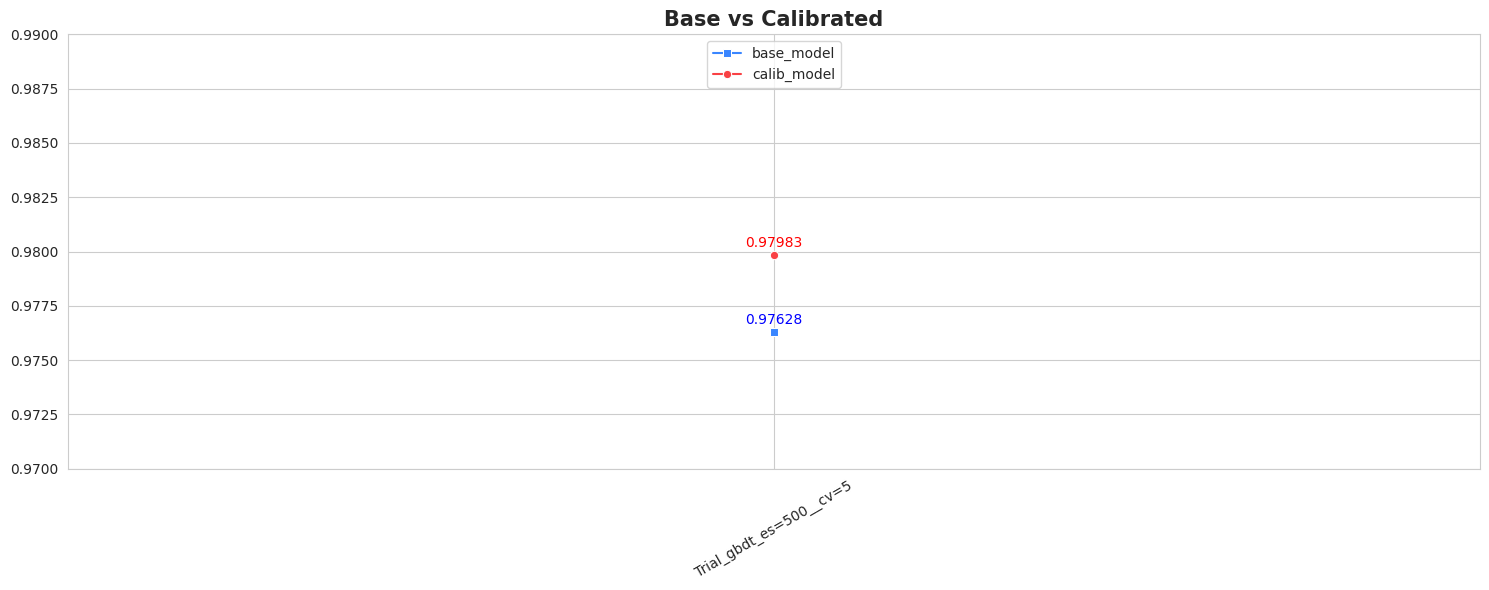

In [49]:
all_model_scores = {}

for comp in COMPILER:
    for model_name, item in comp.items():
        for key, value in item.items():
            if key == 'scores':
                all_model_scores[model_name] = value

raw_scores, calib_scores, names = [], [], []

for k, group in all_model_scores.items():
    raw_scores.append(group[0])
    calib_scores.append(group[1])
    names.append(k)

plt.figure(figsize=(15, 6))
ax1 = sns.lineplot(raw_scores,   marker='s', label='base_model')
ax2 = sns.lineplot(calib_scores, marker='o', label='calib_model')

y_add = 4e-4

for i, s1 in enumerate(raw_scores):
    ax1.text(float(i), s1+y_add, s1, ha='center', va='baseline', color='b')

for i, s2 in enumerate(calib_scores):
    ax2.text(float(i), s2+y_add, s2, ha='center', va='baseline', color='r')

plt.ylim((0.97, 0.99))
plt.legend(loc='upper center')
plt.xticks(range(len(names)), names, rotation=30)
plt.title('Base vs Calibrated', fontdict={'weight': 'semibold', 'size': 15})

plt.tight_layout() 
plt.show()

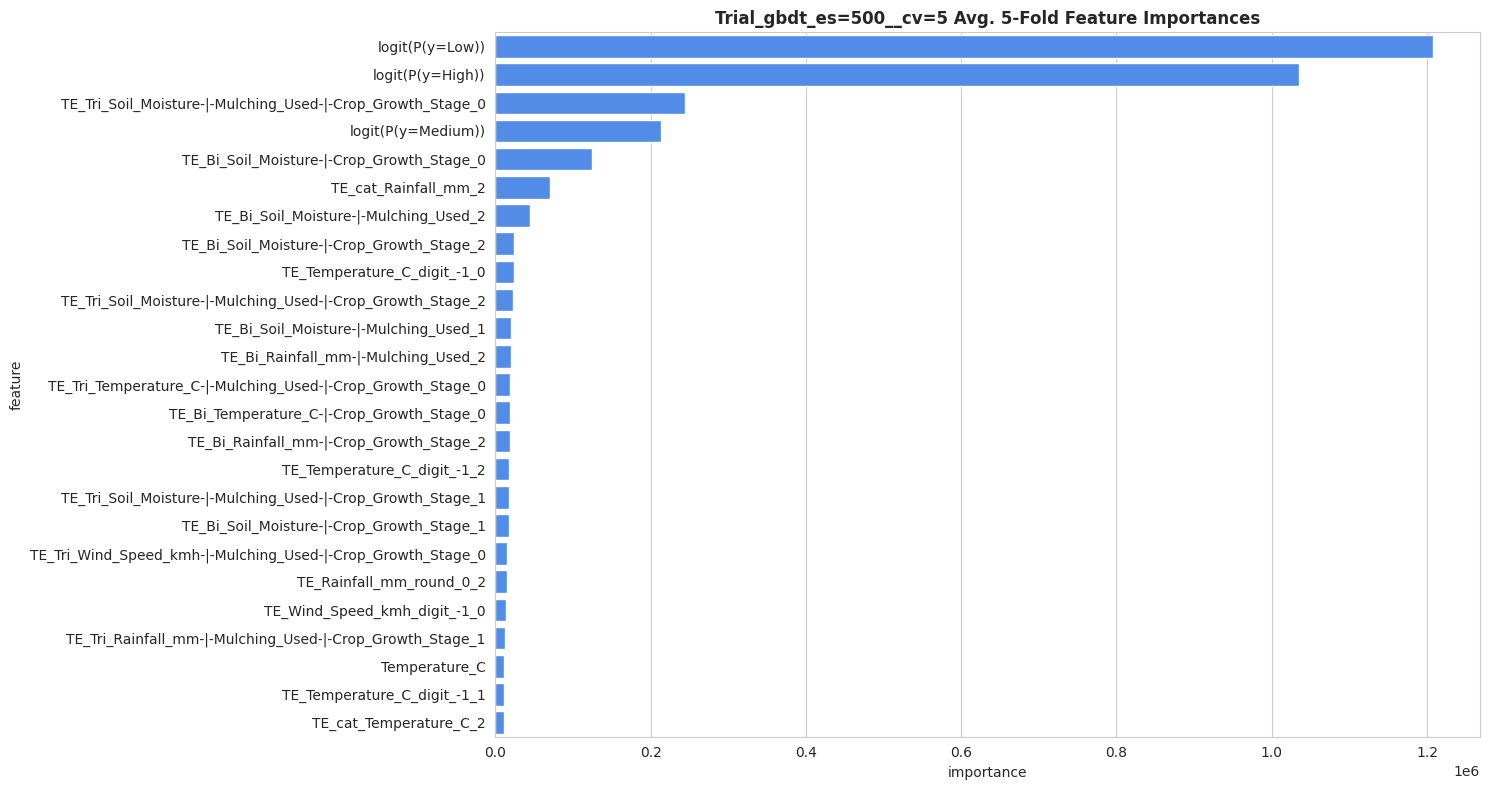

In [50]:
all_feat_importances = {}
all_val_data = {}

for comp in COMPILER:
    for model_name, item in comp.items():
        for key, value in item.items():
            if key == 'importances':
                all_feat_importances[model_name] = np.mean(value, axis=0)
            elif key == 'val_data':
                all_val_data[model_name] = value # -> [0] select X_val, [1] select y_val

top_n = 25

for i, (model, imp) in enumerate(all_feat_importances.items()):
    plt.figure(figsize=(15, 8))
    # plt.subplot(len(all_feat_importances), 1, i+1)
    imp_df = pd.DataFrame({
        'feature': all_val_data[model][0].columns,
        'importance': imp,
    }).sort_values(by='importance', ascending=False).reset_index(drop=True).head(top_n)
    sns.barplot(data=imp_df, x='importance', y='feature')
    plt.title(f'{model} Avg. {N_SPLITS}-Fold Feature Importances', fontweight='semibold')

    plt.tight_layout() 
    plt.show()

    print()

In [51]:
# M_NAME = f"{version_name}bag_"

# LR = 0.05
# # DEPTH = 7
# LEAVES = 31

# PARAMS = {
#     # 'boosting': 'dart',
#     # ----------------------------
#     'objective': 'multiclass',
#     'metric': 'multiclass',
#     'n_estimators': 10_000,
#     'learning_rate': LR,
#     'max_leaves': LEAVES,
#     # 'max_depth': DEPTH,
#     'feature_fraction': 0.4,
#     'bagging_fraction': 0.9,
#     'bagging_freq': 1,
#     'reg_alpha': 10.0,
#     'reg_lambda': 5.0,
#     'random_state': SEED,
#     'verbosity': -1,
#     'n_jobs': os.cpu_count(),
#     'device': 'gpu' if torch.cuda.is_available() else 'cpu',
# }

# # n = n = M_NAME + str(DEPTH) + '_' + str(LR).split('.')[1]
# # all_model_predictions[n] = Trainer_CV(
# #     model_name=n,
# #     params=PARAMS,
# #     train_df=train,
# #     test_df=test,
# #     features=FEATURES,
# #     target=TARGET,
# #     kf=kf,
# #     cats=CATS+DIGITS+['cat_tenure'],
# # )

# VALUES = [0.05]

# for value in VALUES:
#     PARAMS['learning_rate'] = value
#     n = M_NAME + str(LEAVES) + '_' + str(value).split('.')[1]
#     all_model_predictions[n] = Trainer_CV(
#         model_name=n,
#         params=PARAMS,
#         train_df=train,
#         test_df=test,
#         features=FEATURES,
#         target=TARGET,
#         kf=kf,
#         cats=CATS+FORMULA_FLAGS,
#     )

In [52]:
# M_NAME = f"{version_name}goss_"

# PARAMS = {
#     # 'boosting': 'dart',
#     # ---------------------------------
#     'data_sample_strategy': 'goss',
#     'top_rate': 0.4,
#     'other_rate': 0.2,
#     # ---------------------------------
#     'objective': 'multiclass',
#     'metric': 'multiclass',
#     'n_estimators': 10_000,
#     'learning_rate': LR,
#     'max_leaves': LEAVES,
#     # 'max_depth': DEPTH,
#     'feature_fraction': 0.2,
#     'reg_alpha': 10.0,
#     'reg_lambda': 5.0,
#     'random_state': SEED,
#     'verbosity': -1,
#     'n_jobs': os.cpu_count(),
#     'device': 'gpu' if torch.cuda.is_available() else 'cpu',
# }

# # n = M_NAME + str(DEPTH) + '_' + str(LR).split('.')[1]
# # all_model_predictions[n] = Trainer_CV(
# #     model_name=n,
# #     params=PARAMS,
# #     train_df=train,
# #     test_df=test,
# #     features=FEATURES,
# #     target=TARGET,
# #     kf=kf,
# #     cats=CATS+DIGITS+['cat_tenure'],
# # )

# for value in VALUES:
#     PARAMS['learning_rate'] = value
#     n = M_NAME + str(LEAVES) + '_' + str(value).split('.')[1]
#     all_model_predictions[n] = Trainer_CV(
#         model_name=n,
#         params=PARAMS,
#         train_df=train,
#         test_df=test,
#         features=FEATURES,
#         target=TARGET,
#         kf=kf,
#         cats=CATS+FORMULA_FLAGS,
#     )

In [53]:
# all_feat_importances = {}
# all_val_data = {}

# for i, (k, v) in enumerate(all_model_predictions.items()):
#     for x, y in v.items():
#         if x == 'importances':
#             all_feat_importances[k] = np.mean(y, axis=0)
#         elif x == 'val_data':
#             all_val_data[k] = y # -> [0] select X_val, [1] select y_val

# top_n = 25

# for i, (m, fi) in enumerate(all_feat_importances.items()):
#     plt.figure(figsize=(15, 8))
#     # plt.subplot(len(all_feat_importances), 1, i+1)
#     fi_df = pd.DataFrame({
#         'feature': all_val_data[m][0].columns,
#         'importance': fi,
#     }).sort_values(by='importance', ascending=False).reset_index(drop=True).head(top_n)
#     sns.barplot(data=fi_df, x='importance', y='feature')
#     plt.title(f'{m} Avg. {N_SPLITS}-Fold Feature Importances', fontweight='semibold')

#     plt.tight_layout() 
#     plt.show()
#     print()

In [54]:
# all_model_scores = {}

# for i, (k, v) in enumerate(all_model_predictions.items()):
#     for x, y in v.items():
#         if x == 'scores':
#             all_model_scores[k] = y

# raw_scores, calib_scores, names = [], [], []

# for k, group in all_model_scores.items():
#     raw_scores.append(group[0])
#     calib_scores.append(group[1])
#     names.append(k)

# plt.figure(figsize=(15, 5))
# ax1 = sns.lineplot(raw_scores, marker='s', label='xgb_model')
# ax2 = sns.lineplot(calib_scores, marker='o', label='calib_model')

# y_add = 5e-4

# for i, s1 in enumerate(raw_scores):
#     ax1.text(float(i), s1+y_add, s1, ha='center', va='baseline', color='b')

# for i, s2 in enumerate(calib_scores):
#     ax2.text(float(i), s2+y_add, s2, ha='center', va='baseline', color='r')

# plt.ylim((0.97, 0.99))
# plt.legend(loc='upper center')
# plt.xticks(range(len(names)), names, rotation=20)
# plt.title('XGB vs Calibrated', fontdict={'weight': 'semibold', 'size': 15})

# plt.tight_layout() 
# plt.show()

In [55]:
# !rm -r /kaggle/working

In [56]:
## -- Get OOF PREDICTIONS --
for i, (k, v) in enumerate(all_model_predictions.items()):
    for x, y in v.items():
        if x == 'oof_preds':
            ## -- Create base submission file --
            base_n = f"{k}_{str(raw_scores[i]).split('.')[1]}"
            np.save(f"oof_base_{base_n}_.npy", y[0])
            print(f'OOF file for base model saved!')

            ## -- Create calib submission file --
            cal_n = f"{k}_{str(calib_scores[i]).split('.')[1]}"
            np.save(f"oof_calib_{cal_n}_.npy", y[1])
            print(f'OOF file for calibrated model saved!')
            
            print()


OOF file for base model saved!
OOF file for calibrated model saved!



In [57]:
## -- Get TEST PREDICTIONS / SUBMISSIONS --
for i, (k, v) in enumerate(all_model_predictions.items()):
    for j, (x, y) in enumerate(v.items()):
        if x == 'test_preds':
            ## -- Base submission file --
            base_n_1 = f"{k}_{str(raw_scores[i]).split('.')[1]}"
            np.save(f"test_base_{base_n_1}_.npy", y[0])
            base_preds = np.argmax(y[0], axis=1)
            submit[TARGET] = pd.Series(base_preds).map(mapping_r)
            submit.to_csv(f'submit_base_{base_n_1}_.csv', index=False)
            print(f'Submission base TEST file saved! {base_preds.shape}')

            ## -- Calib submission file --
            cal_n_1 = f"{k}_{str(calib_scores[i]).split('.')[1]}"
            np.save(f"test_calib_{cal_n_1}_.npy", y[1])
            calib_preds = np.argmax(y[1], axis=1)
            submit[TARGET] = pd.Series(calib_preds).map(mapping_r)
            submit.to_csv(f'submit_calib_{cal_n_1}_.csv', index=False)
            print(f'Submission calib TEST file saved! {calib_preds.shape}')

            print()

Submission base TEST file saved! (270000,)
Submission calib TEST file saved! (270000,)



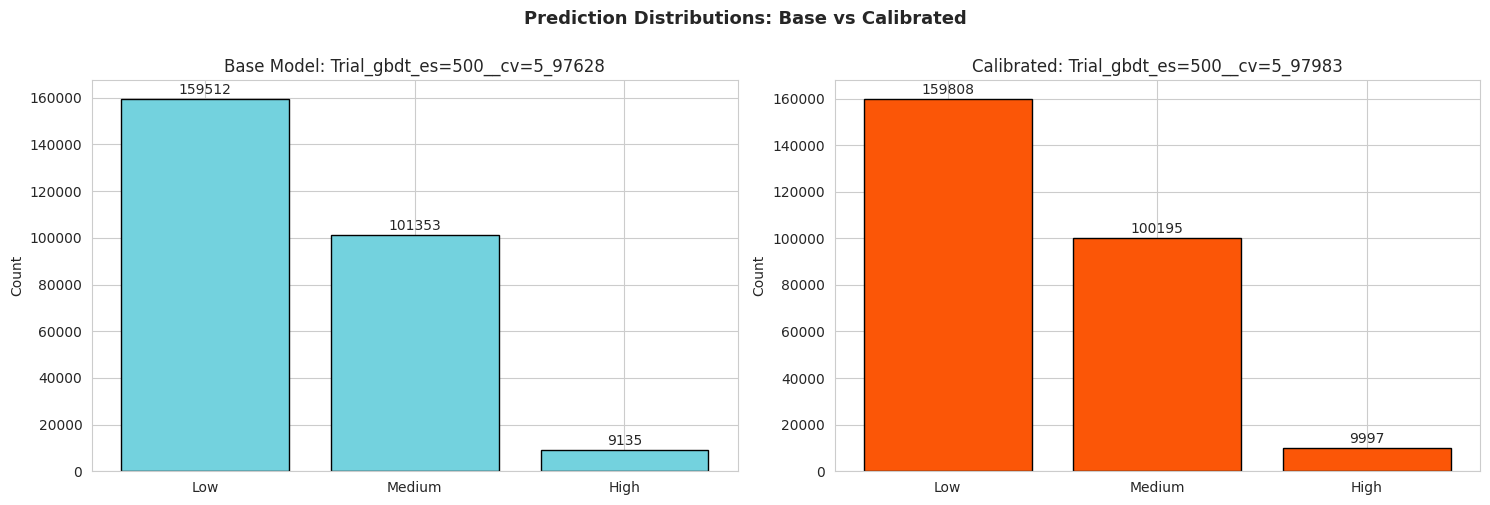

In [58]:
class_names = [k for k in mapping.keys()]
fig, axes = plt.subplots(1, 2, figsize=(15, 5))

for ax, preds, title, color in [
    (axes[0], base_preds, f'Base Model: {base_n_1}', '#73D2DE'),
    (axes[1], calib_preds, f'Calibrated: {cal_n_1}', '#FB5607'),
]:
    counts = [np.sum(preds == i) for i in range(len(np.unique(base_preds)))]
    ax.bar(class_names, counts, color=color, edgecolor='k')
    ax.set_title(title)
    ax.set_ylabel('Count')

    for i, c in enumerate(counts):
        ax.text(i, c + 2000, str(c), ha='center', fontsize=10)

plt.suptitle('Prediction Distributions: Base vs Calibrated', fontsize=13, y=1.00, fontweight='semibold')

plt.tight_layout()
plt.show()